
##**EMAI-641: Deep learning - Final Project**

**Implicit Tourist Experience Evaluation Using
Deep Learning and Facial Expression**




---


##Import Libraries

In [ ]:
!pip install gradio
!pip install kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.4/320.4 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 123.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [ ]:
import os
import cv2
import random
import shutil
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.utils import plot_model
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.callbacks import ModelCheckpoint
import gradio as gr
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array, load_img

from google.colab.patches import cv2_imshow
from google.colab import files


##Dataset Loading

In [ ]:
!kaggle datasets download -d yakhyokhuja/affectnetaligned -p /content

Dataset URL: https://www.kaggle.com/datasets/yakhyokhuja/affectnetaligned
License(s): other
 97% 241M/249M [00:04<00:00, 72.9MB/s]
100% 249M/249M [00:04<00:00, 64.1MB/s]


In [ ]:
!unzip /content/affectnetaligned.zip

Streaming output truncated to the last 5000 lines.
  inflating: AffectNetCustom/train/6/image0016315.jpg  
  inflating: AffectNetCustom/train/6/image0016316.jpg  
  inflating: AffectNetCustom/train/6/image0016318.jpg  
  inflating: AffectNetCustom/train/6/image0016319.jpg  
  inflating: AffectNetCustom/train/6/image0016324.jpg  
  inflating: AffectNetCustom/train/6/image0016332.jpg  
  inflating: AffectNetCustom/train/6/image0016333.jpg  
  inflating: AffectNetCustom/train/6/image0016336.jpg  
  inflating: AffectNetCustom/train/6/image0016340.jpg  
  inflating: AffectNetCustom/train/6/image0016343.jpg  
  inflating: AffectNetCustom/train/6/image0016344.jpg  
  inflating: AffectNetCustom/train/6/image0016347.jpg  
  inflating: AffectNetCustom/train/6/image0016354.jpg  
  inflating: AffectNetCustom/train/6/image0016358.jpg  
  inflating: AffectNetCustom/train/6/image0016363.jpg  
  inflating: AffectNetCustom/train/6/image0016364.jpg  
  inflating: AffectNetCustom/train/6/image0016367.jpg

###Emotion Label Mapping and Folder Renaming

In [ ]:
dataset_path = '/content/AffectNetCustom'

# Emotion labels mapping
emotion_map = {
    "0": "Angry",
    # "1": "Disgust",
    "2": "Fear",
    "3": "Happy",
    "4": "Sad",
    "5": "Surprise",
    "6": "Neutral",
    # "7": "Contempt"
}

# Function to rename (train, val, test) folders
def rename_folders(base_folder, emotion_map):
    for numeric_label, emotion_label in emotion_map.items():
        old_folder_path = os.path.join(base_folder, numeric_label)
        new_folder_path = os.path.join(base_folder, emotion_label)

        # Rename folder if the old folder exists and new folder doesn't already exist
        if os.path.isdir(old_folder_path):
            if not os.path.exists(new_folder_path):
                os.rename(old_folder_path, new_folder_path)
                print(f"Renamed folder '{numeric_label}' to '{emotion_label}'")
            else:
                print(f"Folder '{emotion_label}' already exists.")

#Paths to the train, val, and test folders
train_folder = os.path.join(dataset_path, 'train')
val_folder = os.path.join(dataset_path, 'val')
test_folder = os.path.join(dataset_path, 'test')

# Rename folders in each dataset split
rename_folders(train_folder, emotion_map)
rename_folders(val_folder, emotion_map)
rename_folders(test_folder, emotion_map)

Renamed folder '0' to 'Angry'
Renamed folder '2' to 'Fear'
Renamed folder '3' to 'Happy'
Renamed folder '4' to 'Sad'
Renamed folder '5' to 'Surprise'
Renamed folder '6' to 'Neutral'
Renamed folder '0' to 'Angry'
Renamed folder '2' to 'Fear'
Renamed folder '3' to 'Happy'
Renamed folder '4' to 'Sad'
Renamed folder '5' to 'Surprise'
Renamed folder '6' to 'Neutral'
Renamed folder '0' to 'Angry'
Renamed folder '2' to 'Fear'
Renamed folder '3' to 'Happy'
Renamed folder '4' to 'Sad'
Renamed folder '5' to 'Surprise'
Renamed folder '6' to 'Neutral'


## Dataset Preperation

###Dataset Utilization for Hierarchical Classification

In [ ]:
# Create the parent directory
def filter_parent(base_folder, target_classes, output_folder, parent_label):
    parent_folder = os.path.join(output_folder, parent_label)
    os.makedirs(parent_folder, exist_ok=True)
    for emotion in target_classes:
        src_folder = os.path.join(base_folder, emotion)
        if os.path.isdir(src_folder):
            for file in os.listdir(src_folder):
                src = os.path.join(src_folder, file)
                dst = os.path.join(parent_folder, file)
                tf.io.gfile.copy(src, dst)
        else:
            print(f"Source folder does not exist: {src_folder}")

# Create the child directory
def filter_child(base_folder, target_classes, output_folder):
    os.makedirs(output_folder, exist_ok=True)
    for emotion in target_classes:
        src_folder = os.path.join(base_folder, emotion)
        dst_folder = os.path.join(output_folder, emotion)
        os.makedirs(dst_folder, exist_ok=True)
        if os.path.isdir(src_folder):
            for file in os.listdir(src_folder):
                src = os.path.join(src_folder, file)
                dst = os.path.join(dst_folder, file)
                tf.io.gfile.copy(src, dst)

In [ ]:
# Define class groups for hierarchical classification
# positive_classes = ["Happy", "Surprise", "Neutral"]
# negative_classes = ["Angry", "Disgust", "Fear", "Sad", "Contempt"]

positive_classes = ["Happy", "Surprise", "Neutral"]
negative_classes = ["Angry", "Fear", "Sad"]  # Excludes Disgust and Contempt


# Output datasets paths
output_folders = {
    "parent": {
        "train": "/content/ParentDataset/train",
        "val": "/content/ParentDataset/val",
        "test": "/content/ParentDataset/test",},

    "positive": {
        "train": "/content/PositiveDataset/train",
        "val": "/content/PositiveDataset/val",
        "test": "/content/PositiveDataset/test", },

    "negative": {
        "train": "/content/NegativeDataset/train",
        "val": "/content/NegativeDataset/val",
        "test": "/content/NegativeDataset/test",}
}

# Filter datasets for the parent classifier
filter_parent(train_folder, positive_classes, output_folders["parent"]["train"], parent_label="Positive")
filter_parent(train_folder, negative_classes, output_folders["parent"]["train"], parent_label="Negative")

filter_parent(val_folder, positive_classes, output_folders["parent"]["val"], parent_label="Positive")
filter_parent(val_folder, negative_classes, output_folders["parent"]["val"], parent_label="Negative")

filter_parent(test_folder, positive_classes, output_folders["parent"]["test"], parent_label="Positive")
filter_parent(test_folder, negative_classes, output_folders["parent"]["test"], parent_label="Negative")

# Filter datasets for positive classifier
filter_child(train_folder, positive_classes, output_folders["positive"]["train"])
filter_child(val_folder, positive_classes, output_folders["positive"]["val"])
filter_child(test_folder, positive_classes, output_folders["positive"]["test"])

# Filter datasets for negative classifier
filter_child(train_folder, negative_classes, output_folders["negative"]["train"])
filter_child(val_folder, negative_classes, output_folders["negative"]["val"])
filter_child(test_folder, negative_classes, output_folders["negative"]["test"])


###Dataset Statistics

In [ ]:
import os

def calculate_dataset_statistics(base_folder):
    """
    Calculate the length and labels of datasets in a folder.
    Args:
        base_folder (str): Path to the dataset folder.
    Returns:
        dict: A dictionary with class labels as keys and number of images as values.
    """
    statistics = {}
    for label in os.listdir(base_folder):
        class_folder = os.path.join(base_folder, label)
        if os.path.isdir(class_folder):
            statistics[label] = len(os.listdir(class_folder))  # Count images in the class folder
    return statistics

# Print dataset statistics
def print_statistics(dataset_name, train_folder, val_folder, test_folder):
    print(f"\n{dataset_name.upper()} DATASET STATISTICS:")
    print("Train:", calculate_dataset_statistics(train_folder))
    print("Validation:", calculate_dataset_statistics(val_folder))
    print("Test:", calculate_dataset_statistics(test_folder))

# Paths to the dataset folders
print_statistics("Parent", output_folders["parent"]["train"], output_folders["parent"]["val"], output_folders["parent"]["test"])
print_statistics("Positive", output_folders["positive"]["train"], output_folders["positive"]["val"], output_folders["positive"]["test"])
print_statistics("Negative", output_folders["negative"]["train"], output_folders["negative"]["val"], output_folders["negative"]["test"])



PARENT DATASET STATISTICS:
Train: {'Positive': 14991, 'Negative': 14996}
Validation: {'Positive': 299, 'Negative': 300}
Test: {'Positive': 1199, 'Negative': 1200}

POSITIVE DATASET STATISTICS:
Train: {'Surprise': 4996, 'Happy': 4996, 'Neutral': 4999}
Validation: {'Surprise': 100, 'Happy': 100, 'Neutral': 99}
Test: {'Surprise': 399, 'Happy': 400, 'Neutral': 400}

NEGATIVE DATASET STATISTICS:
Train: {'Fear': 4999, 'Sad': 4998, 'Angry': 4999}
Validation: {'Fear': 100, 'Sad': 100, 'Angry': 100}
Test: {'Fear': 400, 'Sad': 400, 'Angry': 400}


###Data Augmentation for Positive Class



 - To balance the dataset for the parent classifier, we increased the positive samples from approximately 15,000 to align with the nearly 22,542 images in the negative class using data augmentation.

In [ ]:
# # Create an ImageDataGenerator for Positive class augmentation
# positive_augmentation = ImageDataGenerator(
#     rotation_range=20,       # Random rotation
#     width_shift_range=0.2,   # Horizontal shift
#     height_shift_range=0.2,  # Vertical shift
#     shear_range=0.2,         # Shear transformation
#     zoom_range=0.2,          # Random zoom
#     horizontal_flip=True,    # Random horizontal flip
#     fill_mode='nearest'      # Fill mode for empty pixels
# )

# def augment_and_save(generator, input_folder, output_folder, target_count):
#     os.makedirs(output_folder, exist_ok=True)
#     current_count = len(os.listdir(input_folder))
#     image_files = os.listdir(input_folder)

#     i = 0
#     while current_count < target_count:
#         img_path = os.path.join(input_folder, image_files[i % len(image_files)])
#         img = load_img(img_path)  # Load image
#         x = img_to_array(img)  # Convert to NumPy array
#         x = x.reshape((1,) + x.shape)  # Reshape for augmentation

#         # Generate augmented images
#         for batch in generator.flow(x, batch_size=1, save_to_dir=output_folder, save_prefix='aug', save_format='jpeg'):
#             current_count += 1
#             if current_count >= target_count:
#                 break
#         i += 1

# #Augment Positive classes to match Negative class count
# augment_and_save(positive_augmentation,
#                  input_folder="/content/ParentDataset/train/Positive",
#                  output_folder="/content/ParentDataset/train/Positive",
#                  target_count=22542)  # Match the total number of Negative samples

###Data Preprocessing  

In [ ]:
# Data preprocessing
def preprocess_image(img, label):
    img = tf.image.resize(img, (224, 224))  # Resize to 224x224
    img = tf.image.random_flip_left_right(img)  # Random horizontal flip
    img = tf.image.random_brightness(img, 0.2)  # Adjust brightness
    img = tf.image.random_contrast(img, 0.8, 1.2)  # Adjust contrast
    img = tf.cast(img, tf.float32)  # Convert to float32
    img = preprocess_input(img)  # ResNet50-specific preprocessing
    return img, label

def load_dataset(base_folder):
    dataset = tf.keras.utils.image_dataset_from_directory(
        base_folder,
        label_mode="int",  # Integer labels (e.g., 0 for Positive, 1 for Negative)
        image_size=(224, 224),  # Resize images
        batch_size=32,  # Use a batch size of 32
        shuffle=True,
        seed=42,  # Ensure reproducibility
    ).map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
    return dataset

# Load parent dataset (should contain only Positive and Negative)
parent_train = load_dataset(output_folders["parent"]["train"])
parent_val = load_dataset(output_folders["parent"]["val"])
parent_test = load_dataset(output_folders["parent"]["test"])

# Load positive child dataset (should contain only Happy, Surprise, Neutral)
positive_train = load_dataset(output_folders["positive"]["train"])
positive_val = load_dataset(output_folders["positive"]["val"])
positive_test = load_dataset(output_folders["positive"]["test"])

# Load negative child dataset (should contain only Angry, Fear, Sad)
negative_train = load_dataset(output_folders["negative"]["train"])
negative_val = load_dataset(output_folders["negative"]["val"])
negative_test = load_dataset(output_folders["negative"]["test"])


Found 29987 files belonging to 2 classes.
Found 599 files belonging to 2 classes.
Found 2399 files belonging to 2 classes.
Found 14991 files belonging to 3 classes.
Found 299 files belonging to 3 classes.
Found 1199 files belonging to 3 classes.
Found 14996 files belonging to 3 classes.
Found 300 files belonging to 3 classes.
Found 1200 files belonging to 3 classes.


In [ ]:
# # Data preprocessing
# def preprocess_image(img, label):
#     img = tf.image.resize(img, (224, 224))  # Resize to 224x224
#     img = tf.image.random_flip_left_right(img)  # Random horizontal flip
#     img = tf.image.random_brightness(img, 0.2)  # Adjust brightness
#     img = tf.image.random_contrast(img, 0.8, 1.2)  # Adjust contrast
#     img = tf.cast(img, tf.float32)  # Convert to float32
#     img = preprocess_input(img)  # ResNet50-specific preprocessing
#     return img, label

# def load_dataset(base_folder):
#     dataset = image_dataset_from_directory(
#         base_folder,
#         label_mode="int",
#         image_size=(224, 224),
#         batch_size=32,
#         shuffle=True,
#         seed=42,
#     ).map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)
#     return dataset

# # Parent dataset
# parent_train = load_dataset(output_folders["parent"]["train"])
# parent_val = load_dataset(output_folders["parent"]["val"])
# parent_test = load_dataset(output_folders["parent"]["test"])

# # Positive child dataset
# positive_train = load_dataset(output_folders["positive"]["train"])
# positive_val = load_dataset(output_folders["positive"]["val"])
# positive_test = load_dataset(output_folders["positive"]["test"])

# # Negative child dataset
# negative_train = load_dataset(output_folders["negative"]["train"])
# negative_val = load_dataset(output_folders["negative"]["val"])
# negative_test = load_dataset(output_folders["negative"]["test"])

Found 29987 files belonging to 2 classes.
Found 599 files belonging to 2 classes.
Found 2399 files belonging to 2 classes.
Found 14991 files belonging to 3 classes.
Found 299 files belonging to 3 classes.
Found 1199 files belonging to 3 classes.
Found 14996 files belonging to 3 classes.
Found 300 files belonging to 3 classes.
Found 1200 files belonging to 3 classes.


###  Dataset Encoding

In [ ]:
def encode_dataset(dataset):
    images, labels = [], []
    for img_batch, label_batch in dataset:
        images.append(img_batch.numpy())  # Convert images to NumPy arrays
        labels.append(label_batch.numpy())  # Convert labels to NumPy arrays

    # Combine all batches into single arrays
    images = np.concatenate(images, axis=0)
    labels = np.concatenate(labels, axis=0)

    # One-hot encode the labels
    labels = tf.keras.utils.to_categorical(labels)

    return images, labels

In [ ]:
# Encode parent dataset
parent_train_images, parent_train_labels = encode_dataset(parent_train)
parent_val_images, parent_val_labels = encode_dataset(parent_val)
parent_test_images, parent_test_labels = encode_dataset(parent_test)

# Encode positive child dataset
positive_train_images, positive_train_labels = encode_dataset(positive_train)
positive_val_images, positive_val_labels = encode_dataset(positive_val)
positive_test_images, positive_test_labels = encode_dataset(positive_test)

# Encode negative child dataset
negative_train_images, negative_train_labels = encode_dataset(negative_train)
negative_val_images, negative_val_labels = encode_dataset(negative_val)
negative_test_images, negative_test_labels = encode_dataset(negative_test)

# Output validation
print(f"Parent train images shape: {parent_train_images.shape}, labels shape: {parent_train_labels.shape}")
print(f"Positive train images shape: {positive_train_images.shape}, labels shape: {positive_train_labels.shape}")
print(f"Negative train images shape: {negative_train_images.shape}, labels shape: {negative_train_labels.shape}")

Parent train images shape: (29987, 224, 224, 3), labels shape: (29987, 2)
Positive train images shape: (14991, 224, 224, 3), labels shape: (14991, 3)
Negative train images shape: (14996, 224, 224, 3), labels shape: (14996, 3)


In [ ]:
unique, counts = np.unique(parent_train_labels, return_counts=True)
print(dict(zip(["Positive", "Negative"], counts)))

{'Positive': 29987, 'Negative': 29987}


#Developing a Hierarchical Classification Model


## Parent Classifier

### Transfer learning: Building the Parent Classifier Using ResNet-50

In [ ]:
# Load the pre-trained ResNet-50 model without the top layer
def create_parent_classifier(input_shape):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze base model initially

#Custom classification
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(2, activation='softmax')  # Binary classification
    ])

    model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Create model
parent_classifier = create_parent_classifier(input_shape=(224, 224, 3))

# Define callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1)

parent_classifier.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,113,794 (91.99 MB)

 Trainable params: 525,570 (2.00 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

### Model architecture

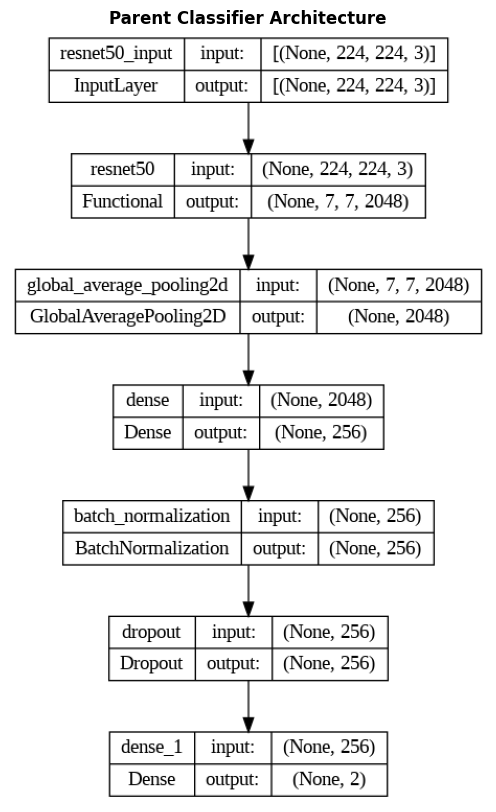

In [ ]:
# Save a plot the model architecture
plot_model( parent_classifier, to_file="parent_classifier_architecture.png", show_shapes=True, show_layer_names=True, rankdir="TB")

# Display the Parent Classifier architecture
img = mpimg.imread("parent_classifier_architecture.png")
plt.figure(figsize=(7, 10))
plt.imshow(img)
plt.title("Parent Classifier Architecture", fontsize=12, weight="bold")
plt.axis('off')
plt.show()

### Model Training

In [ ]:
# Define the callback
checkpoint_callback = ModelCheckpoint(
    filepath="best_parent_classifier_model.keras",  # Save the best model as an HDF5 file
    monitor="val_loss",  # Monitor validation loss
    save_best_only=True,  # Save only when the model improves
    verbose=1
)

history = parent_classifier.fit(parent_train,
                                validation_data=parent_val,
                                epochs=10, batch_size=16, callbacks=[early_stop, reduce_lr,  checkpoint_callback])

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6224 - loss: 0.7717
Epoch 1: val_loss improved from inf to 0.63798, saving model to best_parent_classifier_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 99s 92ms/step - accuracy: 0.6224 - loss: 0.7715 - val_accuracy: 0.6611 - val_loss: 0.6380 - learning_rate: 0.0010
Epoch 2/10
937/938 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6809 - loss: 0.5915
Epoch 2: val_loss improved from 0.63798 to 0.61532, saving model to best_parent_classifier_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 84ms/step - accuracy: 0.6809 - loss: 0.5915 - val_accuracy: 0.6694 - val_loss: 0.6153 - learning_rate: 0.0010
Epoch 3/10
937/938 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6915 - loss: 0.5804
Epoch 3: val_loss improved from 0.61532 to 0.59587, saving model to best_parent_classifier_model.keras
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 84ms/step - accuracy: 0.6915 - loss: 0.5804 - val_accuracy: 0.6745 - val_loss: 0.5959 - learning_rate: 0.0010
Epoch

In [ ]:
# Evaluate baseline performance using the test data generator
parent_baseline = parent_classifier.evaluate(parent_test)

# Print the evaluation metrics (loss and accuracy)
print(f"Parent Baseline Test Results: Loss = {parent_baseline[0]:.4f}, Accuracy = {parent_baseline[1]:.4f}")


75/75 ━━━━━━━━━━━━━━━━━━━━ 10s 134ms/step - accuracy: 0.7277 - loss: 0.5405
Parent Baseline Test Results: Loss = 0.5488, Accuracy = 0.7216


### Fine-Tuning

In [ ]:
# Unfreeze the last 10 layers for fine-tuning
base_model = parent_classifier.layers[0]  # Access the ResNet base model
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Recompile
parent_classifier.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model (fine-tuning)
history_parent = parent_classifier.fit( parent_train_images, parent_train_labels,
                                        validation_data=(parent_val_images, parent_val_labels),
                                        epochs=30, batch_size=32, callbacks=[early_stop, reduce_lr])

Epoch 1/30
1338/1338 [==============================] - 740s 550ms/step - loss: 0.4993 - accuracy: 0.7369 - val_loss: 0.5761 - val_accuracy: 0.6754 - lr: 1.0000e-05
Epoch 2/30
1338/1338 [==============================] - 749s 560ms/step - loss: 0.4976 - accuracy: 0.7373 - val_loss: 0.5754 - val_accuracy: 0.6792 - lr: 1.0000e-05
Epoch 3/30
1338/1338 [==============================] - 732s 547ms/step - loss: 0.5009 - accuracy: 0.7354 - val_loss: 0.5751 - val_accuracy: 0.6792 - lr: 1.0000e-05
Epoch 4/30
1338/1338 [==============================] - 731s 546ms/step - loss: 0.4971 - accuracy: 0.7380 - val_loss: 0.5762 - val_accuracy: 0.6830 - lr: 1.0000e-05
Epoch 5/30
1338/1338 [==============================] - 730s 546ms/step - loss: 0.4978 - accuracy: 0.7389 - val_loss: 0.5759 - val_accuracy: 0.6767 - lr: 1.0000e-05
Epoch 6/30
1338/1338 [==============================] - ETA: 0s - loss: 0.4961 - accuracy: 0.7381
Epoch 6: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.


In [ ]:
# Evaluate the parent model
parent_p_tuned= parent_classifier.evaluate(parent_test_images, parent_test_labels)
print(f"Parent partially Fine-Tuned Test Results: Loss = {parent_p_tuned[0]:.2f}, Accuracy = {parent_p_tuned[1]:.2f}")

100/100 [==============================] - 54s 543ms/step - loss: 0.5752 - accuracy: 0.6896
Parent partially Fine-Tuned Test Results: Loss = 0.58, Accuracy = 0.69


## Parent Model Evaluation

In [ ]:
# Suppress TensorFlow progress messages
tf.get_logger().setLevel('ERROR')

# Define class names for the parent classifier
parent_names = ["Positive", "Negative"]

# Get predictions and true labels
y_pred = []  # To store predictions
y_true = []  # To store true labels

# Loop through the generator to collect predictions and true labels
for images, labels in parent_test:
    preds = parent_classifier.predict(images)
    y_pred.extend(tf.argmax(preds, axis=1).numpy())  # Predicted class indices
    y_true.extend(labels.numpy())  # True class indices

# Convert lists to arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Generate and print the classification report
print("\nParent Classifier Classification Report:")
print(classification_report(y_true, y_pred, target_names=parent_names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━

### Classification Evaluation Plot


Parent Classifier Classification Report:
              precision    recall  f1-score   support

    Positive       0.74      0.64      0.68      1200
    Negative       0.68      0.77      0.72      1199

    accuracy                           0.70      2399
   macro avg       0.71      0.70      0.70      2399
weighted avg       0.71      0.70      0.70      2399



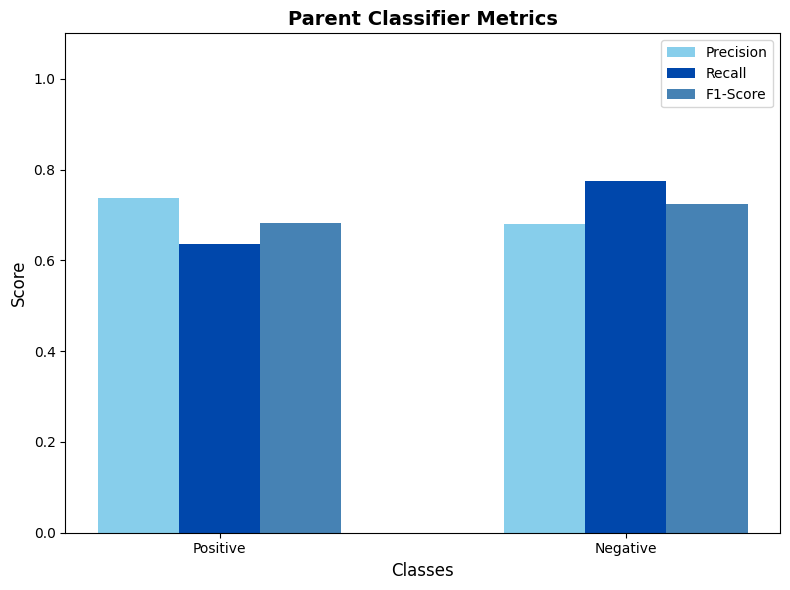

In [ ]:
# Suppress TensorFlow progress messages
tf.get_logger().setLevel('ERROR')

# Define class names for the parent classifier
parent_names = ["Positive", "Negative"]

# Get predictions and true labels
y_pred = []  # To store predictions
y_true = []  # To store true labels

# Loop through the generator to collect predictions and true labels
for images, labels in parent_test:
    preds = parent_classifier.predict(images, verbose=0)  # Suppress progress messages
    y_pred.extend(tf.argmax(preds, axis=1).numpy())  # Predicted class indices
    y_true.extend(labels.numpy())  # True class indices

# Convert lists to arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Generate the classification report
report = classification_report(y_true, y_pred, target_names=parent_names, output_dict=True)

# Print the classification report
print("\nParent Classifier Classification Report:")
print(classification_report(y_true, y_pred, target_names=parent_names))

# Extract metrics for plotting
precision = [report[class_name]['precision'] for class_name in parent_names]
recall = [report[class_name]['recall'] for class_name in parent_names]
f1_score = [report[class_name]['f1-score'] for class_name in parent_names]

# Plot metrics
x = np.arange(len(parent_names))  # X positions for classes
width = 0.2  # Width of bars

plt.figure(figsize=(8, 6))

# Plot Precision
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
# Plot Recall
plt.bar(x, recall, width, label='Recall', color='#0047AB')
# Plot F1-Score
plt.bar(x + width, f1_score, width, label='F1-Score', color='#4682B4')

# Customize the plot
plt.xticks(x, parent_names, fontsize=10)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Parent Classifier Metrics', fontsize=14, weight='bold')
plt.ylim(0, 1.1)  # Set y-axis limit
plt.legend()
plt.tight_layout()
plt.show()


## Confusion Matrix Visualization

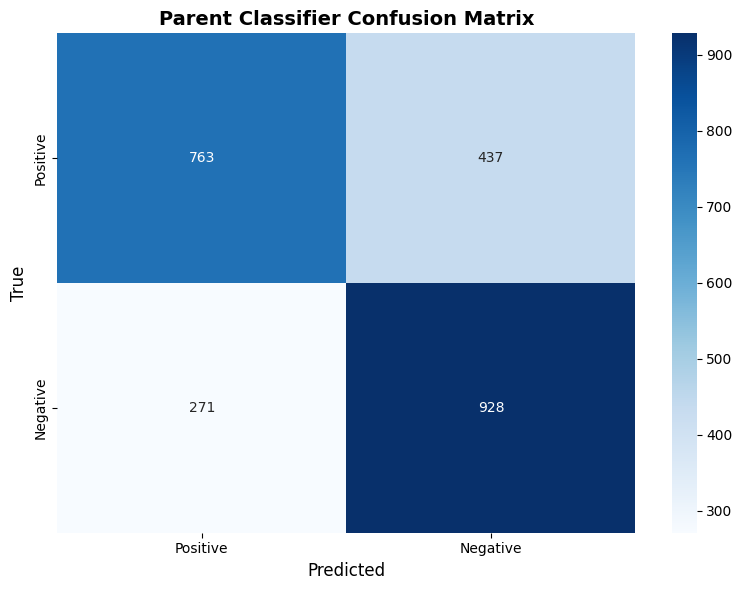

In [ ]:
# Compute the confusion matrix
parent_matrix = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(parent_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=parent_names, yticklabels=parent_names)

# Customize the plot
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Parent Classifier Confusion Matrix', fontsize=14, weight="bold")
plt.tight_layout()  # Adjust layout to fit all elements
plt.show()


## Unfreeze all layers

In [ ]:
# Unfreeze all layers for full fine-tuning
# Unfreeze all layers in the base model
base_model = parent_classifier.layers[0]  # Access the ResNet50 base model
base_model.trainable = True

# Recompile the model with a smaller learning rate
parent_classifier.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model with all layers unfrozen
history_parent_full = parent_classifier.fit(
    parent_train,
    validation_data=parent_val,
    epochs=20,
    batch_size=16,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 341s 307ms/step - accuracy: 0.6194 - loss: 0.6809 - val_accuracy: 0.6277 - val_loss: 0.6814 - learning_rate: 1.0000e-06
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 260s 277ms/step - accuracy: 0.6754 - loss: 0.6062 - val_accuracy: 0.6461 - val_loss: 0.6496 - learning_rate: 1.0000e-06
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 260s 277ms/step - accuracy: 0.7020 - loss: 0.5734 - val_accuracy: 0.6477 - val_loss: 0.6117 - learning_rate: 1.0000e-06
Epoch 4/20
234/938 ━━━━━━━━━━━━━━━━━━━━ 3:13 275ms/step - accuracy: 0.7215 - loss: 0.5526

In [ ]:
# Evaluate Fully fine-tuned performance
parent_tuned= parent_classifier.evaluate(parent_test_images, parent_test_labels)
print(f"Parent Fully Fine-Tuned Test Results: Loss = {parent_tuned[0]:.2f}, Accuracy = {parent_tuned[1]:.2f}")

100/100 [==============================] - 50s 494ms/step - loss: 0.5482 - accuracy: 0.7083
Parent Fully Fine-Tuned Test Results: Loss = 0.55, Accuracy = 0.71


### Model Evaluation

- **Classification Report**

In [ ]:
# Define class names
parent_names = ["Positive", "Negative"]

# Predictions and true labels
y_pred = parent_classifier.predict(parent_test_images)
y_pred_classes= np.argmax(y_pred, axis=1)
y_true = np.argmax(parent_test_labels, axis=1)

# Classification report
print("\n Parent Classifier Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=parent_names))

100/100 [==============================] - 52s 494ms/step

 Parent Classifier Classification Report:
              precision    recall  f1-score   support

    Positive       0.78      0.75      0.76      2000
    Negative       0.60      0.64      0.62      1199

    accuracy                           0.71      3199
   macro avg       0.69      0.69      0.69      3199
weighted avg       0.71      0.71      0.71      3199



- **Parent Classifier Metrics**

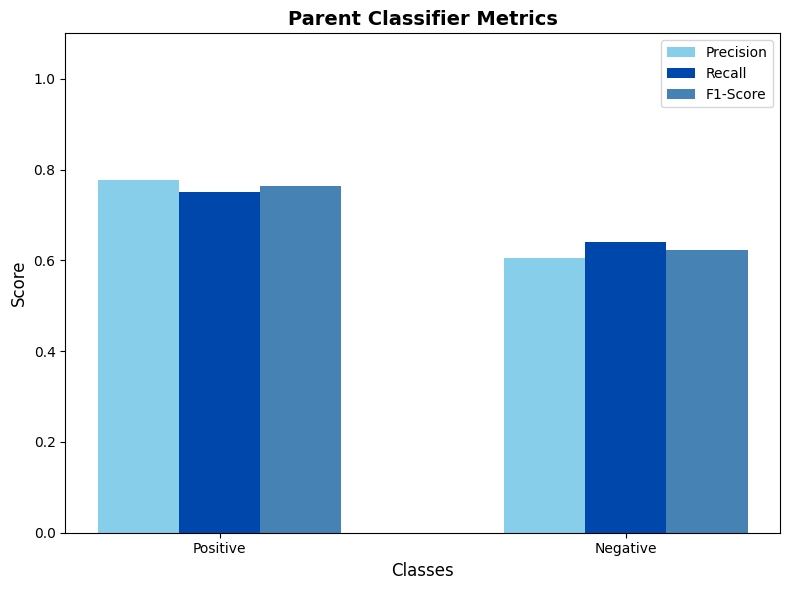

In [ ]:
report = classification_report(y_true, y_pred_classes, target_names=parent_names, output_dict=True)

# Extract metrics
precision = [report[class_name]['precision'] for class_name in parent_names]
recall = [report[class_name]['recall'] for class_name in parent_names]
f1_score = [report[class_name]['f1-score'] for class_name in parent_names]

# Plot metrics
x = np.arange(len(parent_names))  # X positions for classes
width = 0.2  # Width of bars

plt.figure(figsize=(8, 6))

# Plot Precision
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
# Plot Recall
plt.bar(x, recall, width, label='Recall', color='#0047AB')
# Plot F1-Score
plt.bar(x + width, f1_score, width, label='F1-Score', color='#4682B4')

# Customizing the plot
plt.xticks(x, parent_names, fontsize=10)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Parent Classifier Metrics', fontsize=14, weight='bold')
plt.ylim(0, 1.1)  # Set y-axis limit
plt.legend()
plt.tight_layout()
plt.show()


- **Confusion Matrix**

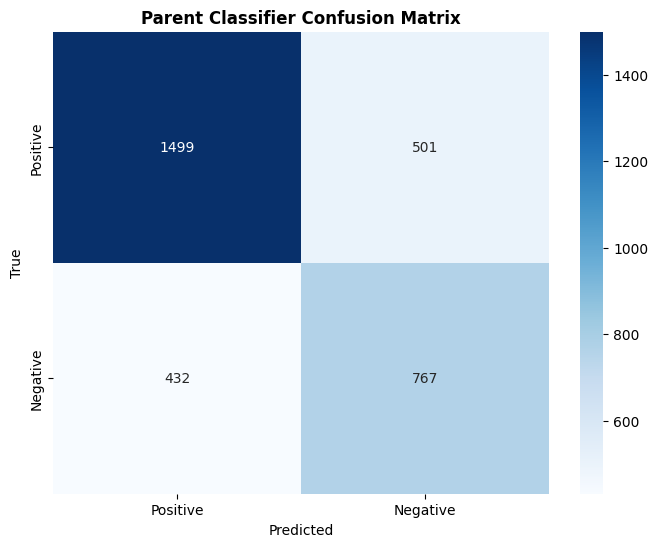

In [ ]:
 # Confusion matrix
parent_matrix = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(parent_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=parent_names, yticklabels=parent_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Parent Classifier Confusion Matrix', weight="bold")
plt.show()

### Parent Classifier Learning Curves


- **Untuned model learning curves**

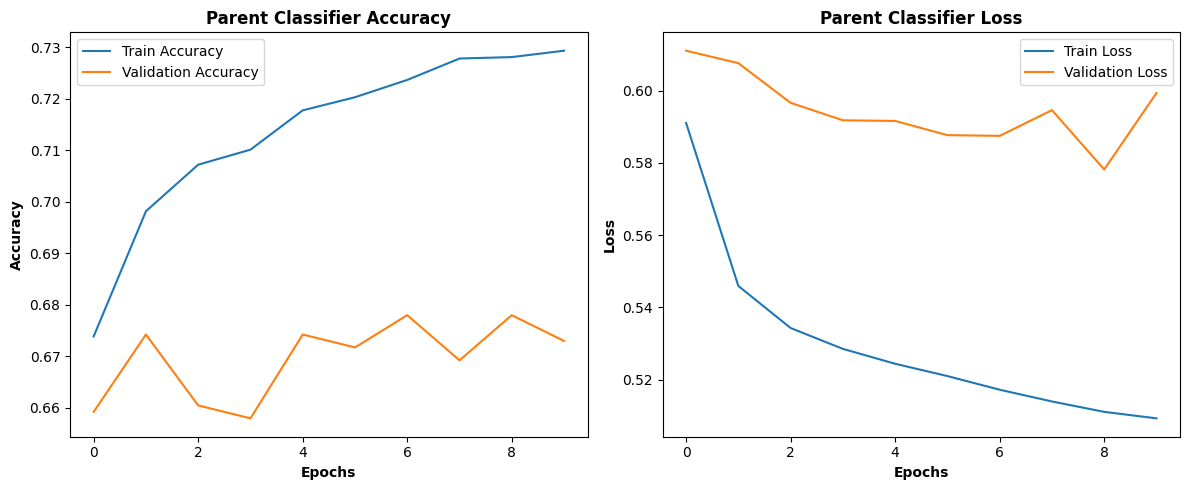

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.title('Parent Classifier Accuracy',weight="bold")
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs',weight="bold")
plt.ylabel('Accuracy',weight="bold")
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.title("Parent Classifier Loss",weight="bold")
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs',weight="bold")
plt.ylabel('Loss',weight="bold")
plt.legend()

plt.tight_layout()
plt.show()

- **Partially Fine-Tuned model learning curves**

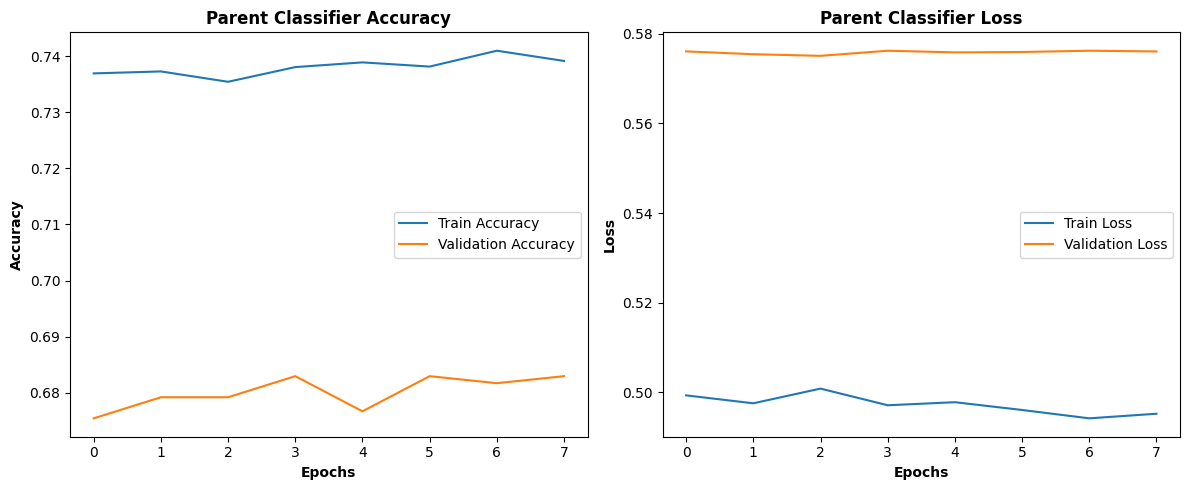

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.title('Parent Classifier Accuracy',weight="bold")
plt.plot(history_parent.history['accuracy'], label='Train Accuracy')
plt.plot(history_parent.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs',weight="bold")
plt.ylabel('Accuracy',weight="bold")
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.title("Parent Classifier Loss",weight="bold")
plt.plot(history_parent.history['loss'], label='Train Loss')
plt.plot(history_parent.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs',weight="bold")
plt.ylabel('Loss',weight="bold")
plt.legend()

plt.tight_layout()
plt.show()

- **Fully fine-tuned model learning curves**

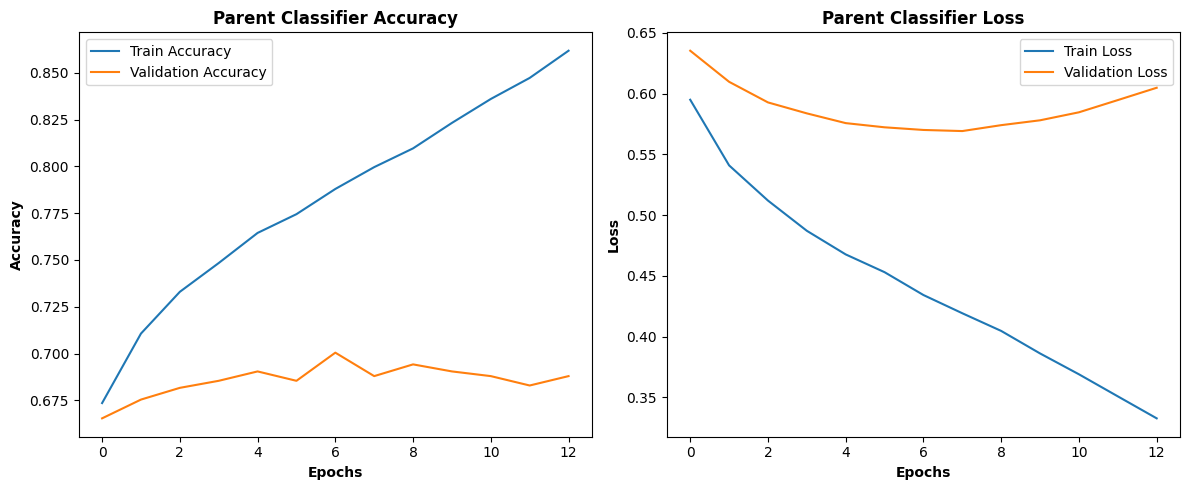

In [ ]:

plt.figure(figsize=(12, 5))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.title('Parent Classifier Accuracy',weight="bold")
plt.plot(history_parent_full.history['accuracy'], label='Train Accuracy')
plt.plot(history_parent_full.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs',weight="bold")
plt.ylabel('Accuracy',weight="bold")
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.title("Parent Classifier Loss",weight="bold")
plt.plot(history_parent_full.history['loss'], label='Train Loss')
plt.plot(history_parent_full.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs',weight="bold")
plt.ylabel('Loss',weight="bold")
plt.legend()

plt.tight_layout()
plt.show()

### Parent Classifier: Predicted vs Actual

1/1 [==============================] - 0s 169ms/step


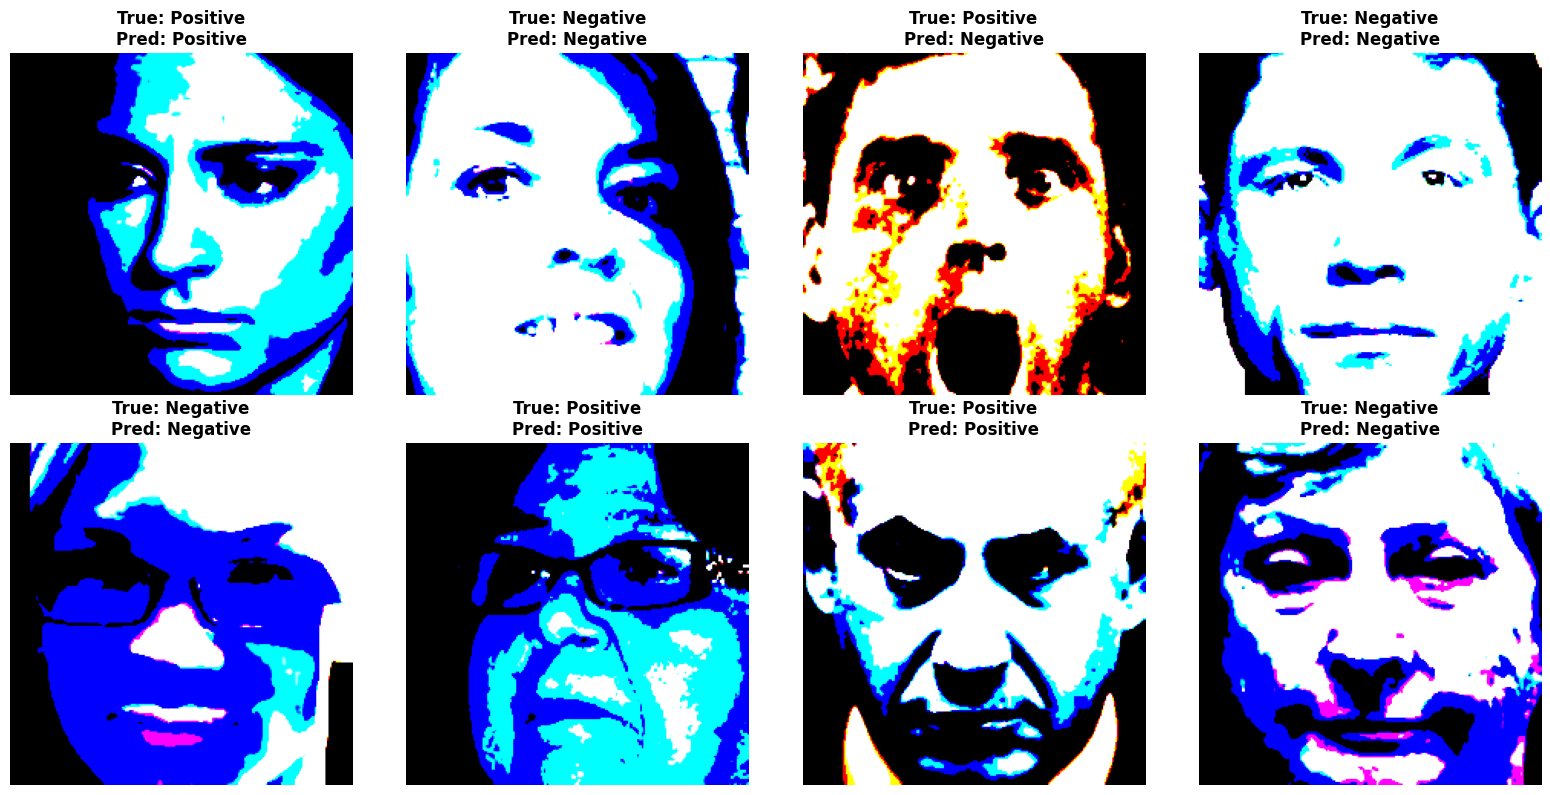

In [ ]:
def plot_predictions_parent(model, images, labels, class_names, num_images=8):

    # Randomly select a subset of images
    indices = np.random.choice(range(len(images)), size=num_images, replace=False)
    selected_images = images[indices]
    selected_labels = labels[indices]

    # Get model predictions
    predictions = model.predict(selected_images)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(selected_labels, axis=1)

    # number of columns (4 per row)
    cols = 4
    rows = (num_images // cols) + (1 if num_images % cols != 0 else 0)

    # Plot the images
    plt.figure(figsize=(cols * 4, rows * 4))
    for i in range(num_images):
        plt.subplot(rows, cols, i + 1)
        img = selected_images[i]

        if img.dtype != np.uint8:
            img = np.clip(img, 0, 1)

        true_label = class_names[true_classes[i]]
        predicted_label = class_names[predicted_classes[i]]
        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {predicted_label}", weight="bold")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Usage
plot_predictions_parent( model=parent_classifier, images=parent_test_images, labels=parent_test_labels,
                        class_names=["Positive", "Negative"], num_images=8)


## Positive Classifier

### Transfer Learning: Building the Positive Classifier Using ResNet-50

In [ ]:
def create_positive_classifier(input_shape, num_classes):
    base_model_P = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model_P.trainable = False  # Freeze all layers initially

    model_P = models.Sequential([
        base_model_P,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])

    model_P.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model_P

# Define input shape and classes
input_shape = (224, 224, 3)
num_classes = 3

# Create the positive classifier
positive_classifier = create_positive_classifier(input_shape, num_classes)

positive_classifier.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,114,051 (91.99 MB)

 Trainable params: 525,827 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

### Model architecture

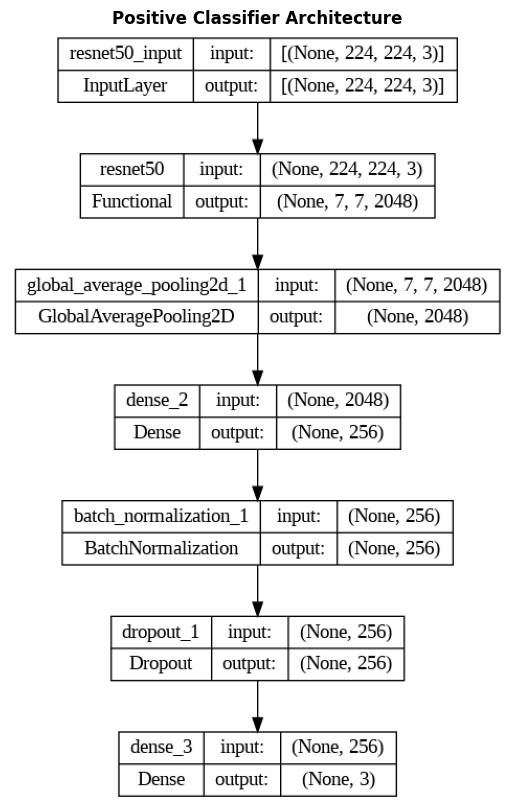

In [ ]:
# Save a plot of the Positive Classifier architecture
plot_model(positive_classifier, to_file="positive_classifier_architecture.png", show_shapes=True, show_layer_names=True, rankdir="TB")

# Display the Positive Classifier architecture
img_positive = mpimg.imread("positive_classifier_architecture.png")
plt.figure(figsize=(7, 10))
plt.imshow(img_positive)
plt.title("Positive Classifier Architecture", fontsize=12, weight="bold")
plt.axis('off')
plt.show()


### Model Training

In [ ]:
# Define the callback to save the best model
checkpoint_callback = ModelCheckpoint(
    filepath="positive_classifier_best.keras",  # Save the model in .keras format
    monitor="val_loss",  # Monitor validation loss
    save_best_only=True,  # Save only the best model
    verbose=1
)

# Train the model with the callback
history_P = positive_classifier.fit(
    positive_train,
    validation_data=positive_val,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop, reduce_lr, checkpoint_callback]
)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5982 - loss: 1.0028
Epoch 1: val_loss improved from inf to 0.65140, saving model to positive_classifier_best.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 61s 109ms/step - accuracy: 0.5983 - loss: 1.0025 - val_accuracy: 0.7291 - val_loss: 0.6514 - learning_rate: 0.0010
Epoch 2/10
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6928 - loss: 0.7201
Epoch 2: val_loss improved from 0.65140 to 0.60848, saving model to positive_classifier_best.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - accuracy: 0.6928 - loss: 0.7201 - val_accuracy: 0.7625 - val_loss: 0.6085 - learning_rate: 0.0010
Epoch 3/10
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7127 - loss: 0.6745
Epoch 3: val_loss did not improve from 0.60848
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 84ms/step - accuracy: 0.7128 - loss: 0.6745 - val_accuracy: 0.7157 - val_loss: 0.6266 - learning_rate: 0.0010
Epoch 4/10
468/469 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7

In [ ]:
# Evaluate baseline performance
positive_Baseline= positive_classifier.evaluate(positive_test)
print(f"Positive Baseline Test Results: Loss = {positive_Baseline[0]:.4f}, Accuracy = {positive_Baseline[1]:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.6799 - loss: 0.7097
Positive Baseline Test Results: Loss = 0.7313, Accuracy = 0.6681


## Positive Classifier Model Evaluation


Positive Classifier Classification Report:
              precision    recall  f1-score   support

       Happy       0.70      0.84      0.76       400
    Surprise       0.59      0.70      0.64       400
     Neutral       0.72      0.45      0.55       399

    accuracy                           0.66      1199
   macro avg       0.67      0.66      0.65      1199
weighted avg       0.67      0.66      0.65      1199



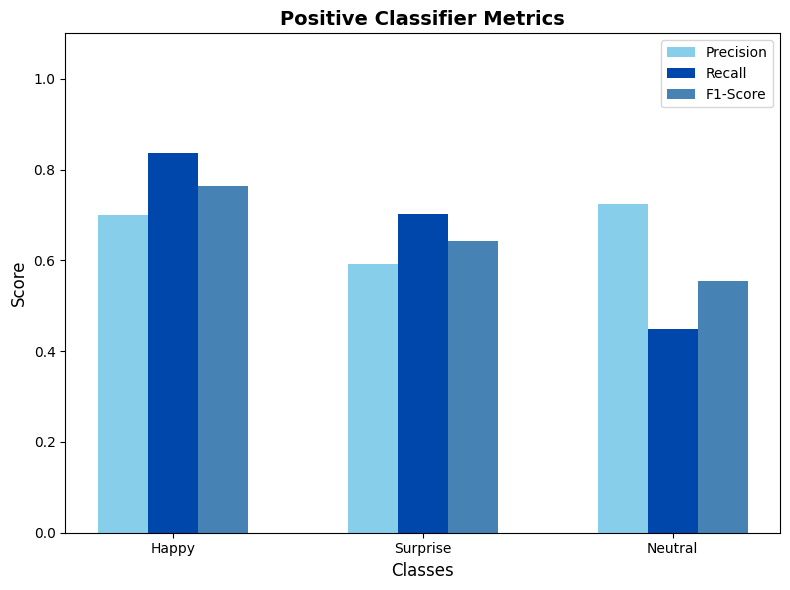

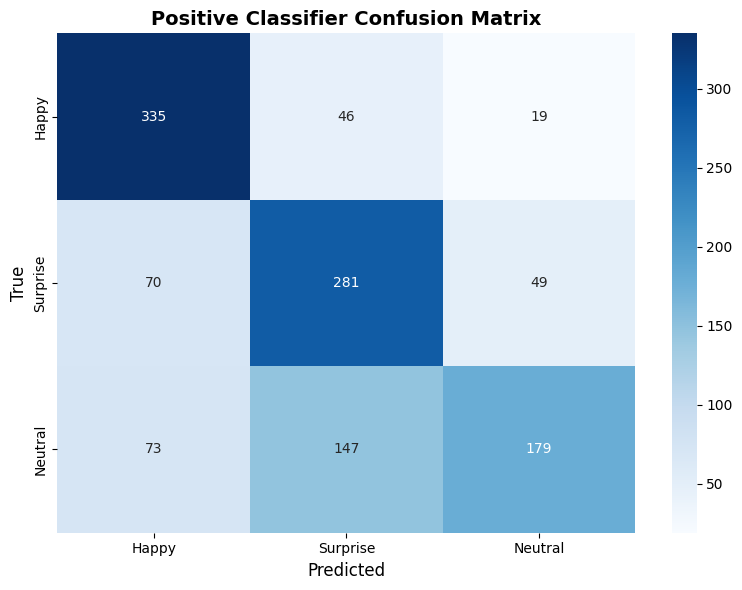

In [ ]:
# Suppress TensorFlow progress messages
tf.get_logger().setLevel('ERROR')

# Define class names for the positive classifier
positive_names = ["Happy", "Surprise", "Neutral"]

# Get predictions and true labels
y_pred = []  # To store predictions
y_true = []  # To store true labels

# Loop through the generator to collect predictions and true labels
for images, labels in positive_test:
    preds = positive_classifier.predict(images, verbose=0)  # Suppress progress messages
    y_pred.extend(tf.argmax(preds, axis=1).numpy())  # Predicted class indices
    y_true.extend(labels.numpy())  # True class indices

# Convert lists to arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Generate the classification report
report = classification_report(y_true, y_pred, target_names=positive_names, output_dict=True)

# Print the classification report
print("\nPositive Classifier Classification Report:")
print(classification_report(y_true, y_pred, target_names=positive_names))

# Extract metrics for plotting
precision = [report[class_name]['precision'] for class_name in positive_names]
recall = [report[class_name]['recall'] for class_name in positive_names]
f1_score = [report[class_name]['f1-score'] for class_name in positive_names]

# Plot metrics
x = np.arange(len(positive_names))  # X positions for classes
width = 0.2  # Width of bars

plt.figure(figsize=(8, 6))

# Plot Precision
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
# Plot Recall
plt.bar(x, recall, width, label='Recall', color='#0047AB')
# Plot F1-Score
plt.bar(x + width, f1_score, width, label='F1-Score', color='#4682B4')

# Customize the plot
plt.xticks(x, positive_names, fontsize=10)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Positive Classifier Metrics', fontsize=14, weight='bold')
plt.ylim(0, 1.1)  # Set y-axis limit
plt.legend()
plt.tight_layout()
plt.show()

# Compute the confusion matrix
positive_matrix = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(positive_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=positive_names, yticklabels=positive_names)

# Customize the plot
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Positive Classifier Confusion Matrix', fontsize=14, weight="bold")
plt.tight_layout()  # Adjust layout to fit all elements
plt.show()


### Fine-Tuning

In [ ]:
# Unfreeze the last 10 layers for fine-tuning
base_model_P = positive_classifier.layers[0]  # Access the ResNet base model
for layer in base_model_P.layers[:-10]:
    layer.trainable = False

# Recompile the model
positive_classifier.compile(optimizer=Adam(learning_rate=1e-5),loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model (fine-tuning)
history_Positive= positive_classifier.fit(positive_train_images, positive_train_labels,
                                          validation_data=(positive_val_images, positive_val_labels),
                                          epochs=20, batch_size=32,callbacks=[early_stop, reduce_lr])

Epoch 1/20
469/469 [==============================] - 255s 536ms/step - loss: 0.5795 - accuracy: 0.7575 - val_loss: 0.5814 - val_accuracy: 0.7659 - lr: 1.0000e-05
Epoch 2/20
469/469 [==============================] - 260s 555ms/step - loss: 0.5715 - accuracy: 0.7637 - val_loss: 0.5777 - val_accuracy: 0.7625 - lr: 1.0000e-05
Epoch 3/20
469/469 [==============================] - 252s 537ms/step - loss: 0.5684 - accuracy: 0.7647 - val_loss: 0.5760 - val_accuracy: 0.7692 - lr: 1.0000e-05
Epoch 4/20
469/469 [==============================] - 257s 547ms/step - loss: 0.5660 - accuracy: 0.7671 - val_loss: 0.5756 - val_accuracy: 0.7759 - lr: 1.0000e-05
Epoch 5/20
469/469 [==============================] - 259s 552ms/step - loss: 0.5622 - accuracy: 0.7651 - val_loss: 0.5748 - val_accuracy: 0.7726 - lr: 1.0000e-05
Epoch 6/20
469/469 [==============================] - 255s 543ms/step - loss: 0.5622 - accuracy: 0.7665 - val_loss: 0.5756 - val_accuracy: 0.7759 - lr: 1.0000e-05
Epoch 7/20
469/469 [==

In [ ]:
# Evaluate partially fine-tuned performance
positive_p_tuned= positive_classifier.evaluate(positive_test_images, positive_test_labels)
print(f"Positive partially Fine-Tuned Test Results: Loss = {positive_p_tuned[0]:.4f}, Accuracy = {positive_p_tuned[1]:.4f}")


38/38 [==============================] - 20s 517ms/step - loss: 0.6625 - accuracy: 0.7223
Positive partially Fine-Tuned Test Results: Loss = 0.6625, Accuracy = 0.7223


In [ ]:
# Unfreeze all layers for full fine-tuning
base_model_P.trainable = True  # Unfreeze all layers

# Recompile the model with a smaller learning rate
positive_classifier.compile(optimizer=Adam(learning_rate=1e-6), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with all layers unfrozen
history_positive_full = positive_classifier.fit( positive_train_images, positive_train_labels,
                                                 validation_data=(positive_val_images, positive_val_labels),
                                                  epochs=20, batch_size=16, callbacks=[early_stop, reduce_lr])


Epoch 1/20
937/937 [==============================] - 981s 1s/step - loss: 0.9207 - accuracy: 0.5949 - val_loss: 0.8206 - val_accuracy: 0.6488 - lr: 1.0000e-06
Epoch 2/20
937/937 [==============================] - 941s 1s/step - loss: 0.7684 - accuracy: 0.6703 - val_loss: 0.7320 - val_accuracy: 0.6823 - lr: 1.0000e-06
Epoch 3/20
937/937 [==============================] - 921s 983ms/step - loss: 0.6951 - accuracy: 0.7005 - val_loss: 0.6850 - val_accuracy: 0.7090 - lr: 1.0000e-06
Epoch 4/20
937/937 [==============================] - 932s 995ms/step - loss: 0.6413 - accuracy: 0.7324 - val_loss: 0.6596 - val_accuracy: 0.7258 - lr: 1.0000e-06
Epoch 5/20
937/937 [==============================] - 917s 979ms/step - loss: 0.6017 - accuracy: 0.7476 - val_loss: 0.6294 - val_accuracy: 0.7425 - lr: 1.0000e-06
Epoch 6/20
937/937 [==============================] - 924s 986ms/step - loss: 0.5632 - accuracy: 0.7643 - val_loss: 0.6137 - val_accuracy: 0.7492 - lr: 1.0000e-06
Epoch 7/20
937/937 [========

In [ ]:
# Evaluate Fully fine-tuned performance
positive_tuned= positive_classifier.evaluate(positive_test_images, positive_test_labels)
print(f"Positive Fully Fine-Tuned Test Results: Loss = {positive_tuned[0]:.4f}, Accuracy = {positive_tuned[1]:.4f}")

38/38 [==============================] - 19s 505ms/step - loss: 0.6214 - accuracy: 0.7364
Positive Fully Fine-Tuned Test Results: Loss = 0.6214, Accuracy = 0.7364


### Model Evaluation

- **Classification Report**

In [ ]:
# Define class names
Positive_names = ["Happy", "Neutral", "Surprise"]

# Predictions and true labels
y_pred_P = positive_classifier.predict(positive_test_images)
y_pred_classes_P = np.argmax(y_pred_P, axis=1)
y_true_P = np.argmax(positive_test_labels, axis=1)

# Classification report
print("\n Positive Classifier Classification Report:")
print(classification_report(y_true_P, y_pred_classes_P, target_names=Positive_names))


38/38 [==============================] - 22s 516ms/step

 Positive Classifier Classification Report:
              precision    recall  f1-score   support

       Happy       0.79      0.81      0.80       400
     Neutral       0.70      0.69      0.69       400
    Surprise       0.72      0.71      0.71       399

    accuracy                           0.74      1199
   macro avg       0.74      0.74      0.74      1199
weighted avg       0.74      0.74      0.74      1199



- **Positive Classifier Metrics**

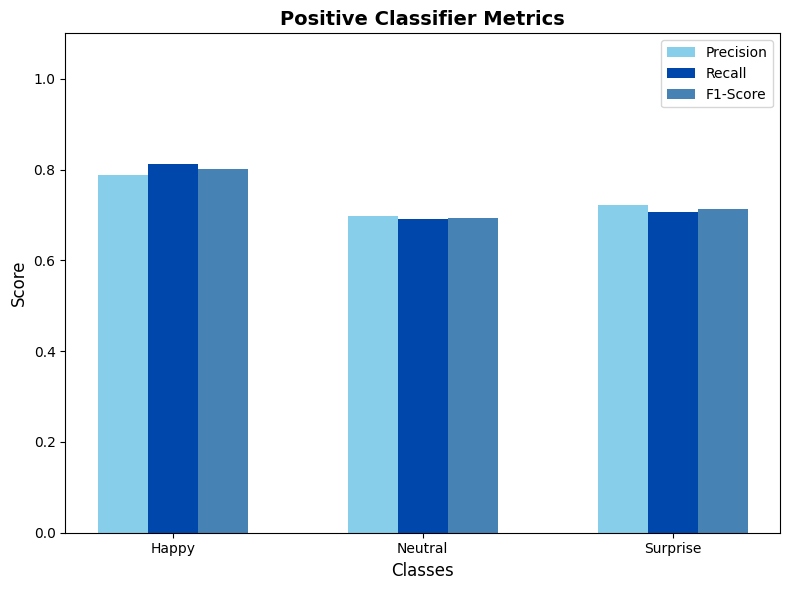

In [ ]:
# Generate Classification Report
report_P = classification_report(y_true_P, y_pred_classes_P, target_names=Positive_names, output_dict=True)

# Extract Metrics
precision_P = [report_P[class_name]['precision'] for class_name in Positive_names]
recall_P = [report_P[class_name]['recall'] for class_name in Positive_names]
f1_score_P = [report_P[class_name]['f1-score'] for class_name in Positive_names]

# Plot Metrics
x = np.arange(len(Positive_names))  # X positions for classes
width = 0.2  # Width of bars

plt.figure(figsize=(8, 6))

# Plot Precision
plt.bar(x - width, precision_P, width, label='Precision', color='skyblue')
# Plot Recall
plt.bar(x, recall_P, width, label='Recall', color='#0047AB')
# Plot F1-Score
plt.bar(x + width, f1_score_P, width, label='F1-Score', color='#4682B4')

# Customizing the plot
plt.xticks(x, Positive_names, fontsize=10)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Positive Classifier Metrics', fontsize=14, weight='bold')
plt.ylim(0, 1.1)  # Set y-axis limit
plt.legend()
plt.tight_layout()
plt.show()


- **Confusion Matrix**

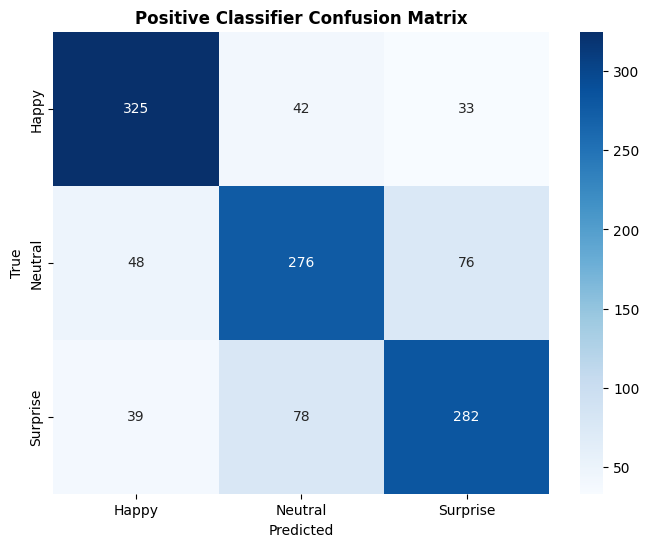

In [ ]:
 # Confusion matrix
Positive_matrix = confusion_matrix(y_true_P, y_pred_classes_P)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(Positive_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=Positive_names, yticklabels=Positive_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Positive Classifier Confusion Matrix', weight="bold")
plt.show()

### Positive Classifier Learning Curves


- **Untuned Positive Classifier learning curves**

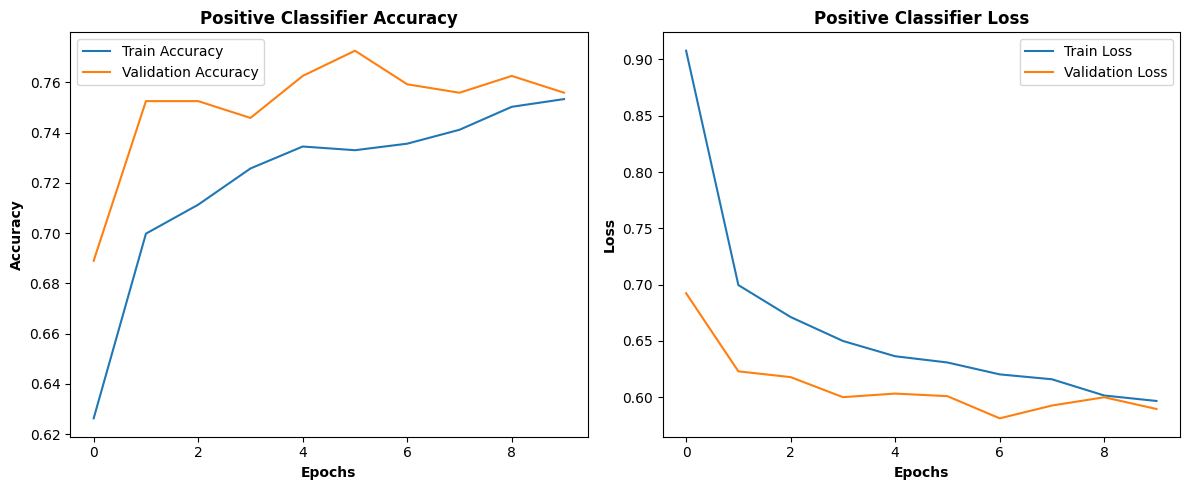

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.title('Positive Classifier Accuracy', weight="bold")
plt.plot(history_P.history['accuracy'], label='Train Accuracy')
plt.plot(history_P.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Accuracy', weight="bold")
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.title("Positive Classifier Loss", weight="bold")
plt.plot(history_P.history['loss'], label='Train Loss')
plt.plot(history_P.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Loss', weight="bold")
plt.legend()

plt.tight_layout()
plt.show()


- **Partially Fine-Tuned Positive Classifier Learning Curves**


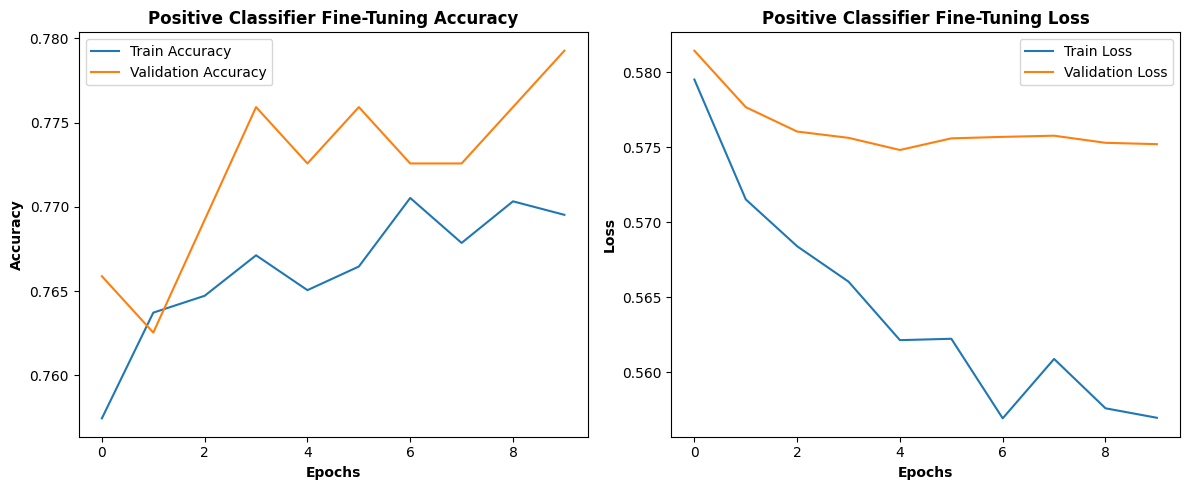

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.title('Positive Classifier Fine-Tuning Accuracy', weight="bold")
plt.plot(history_Positive.history['accuracy'], label='Train Accuracy')
plt.plot(history_Positive.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Accuracy', weight="bold")
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.title("Positive Classifier Fine-Tuning Loss", weight="bold")
plt.plot(history_Positive.history['loss'], label='Train Loss')
plt.plot(history_Positive.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Loss', weight="bold")
plt.legend()

plt.tight_layout()
plt.show()


- **Fully Fine-Tuned Positive Classifier Learning Curves**

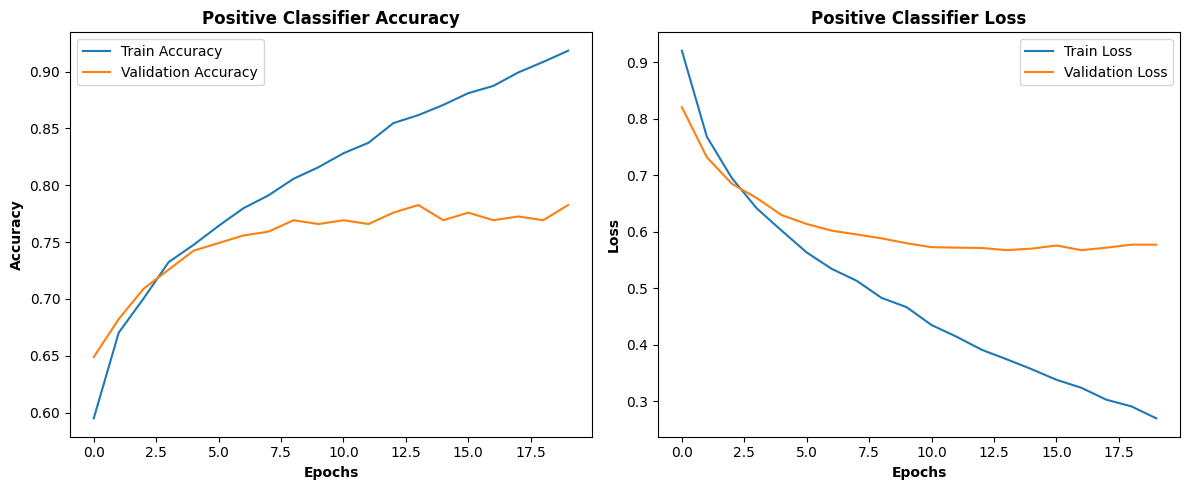

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.title('Positive Classifier Accuracy', weight="bold")
plt.plot(history_positive_full.history['accuracy'], label='Train Accuracy')
plt.plot(history_positive_full.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Accuracy', weight="bold")
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.title("Positive Classifier Loss", weight="bold")
plt.plot(history_positive_full.history['loss'], label='Train Loss')
plt.plot(history_positive_full.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Loss', weight="bold")
plt.legend()

plt.tight_layout()
plt.show()


### Positive Classifier: Predicted vs Actual

1/1 [==============================] - 0s 184ms/step


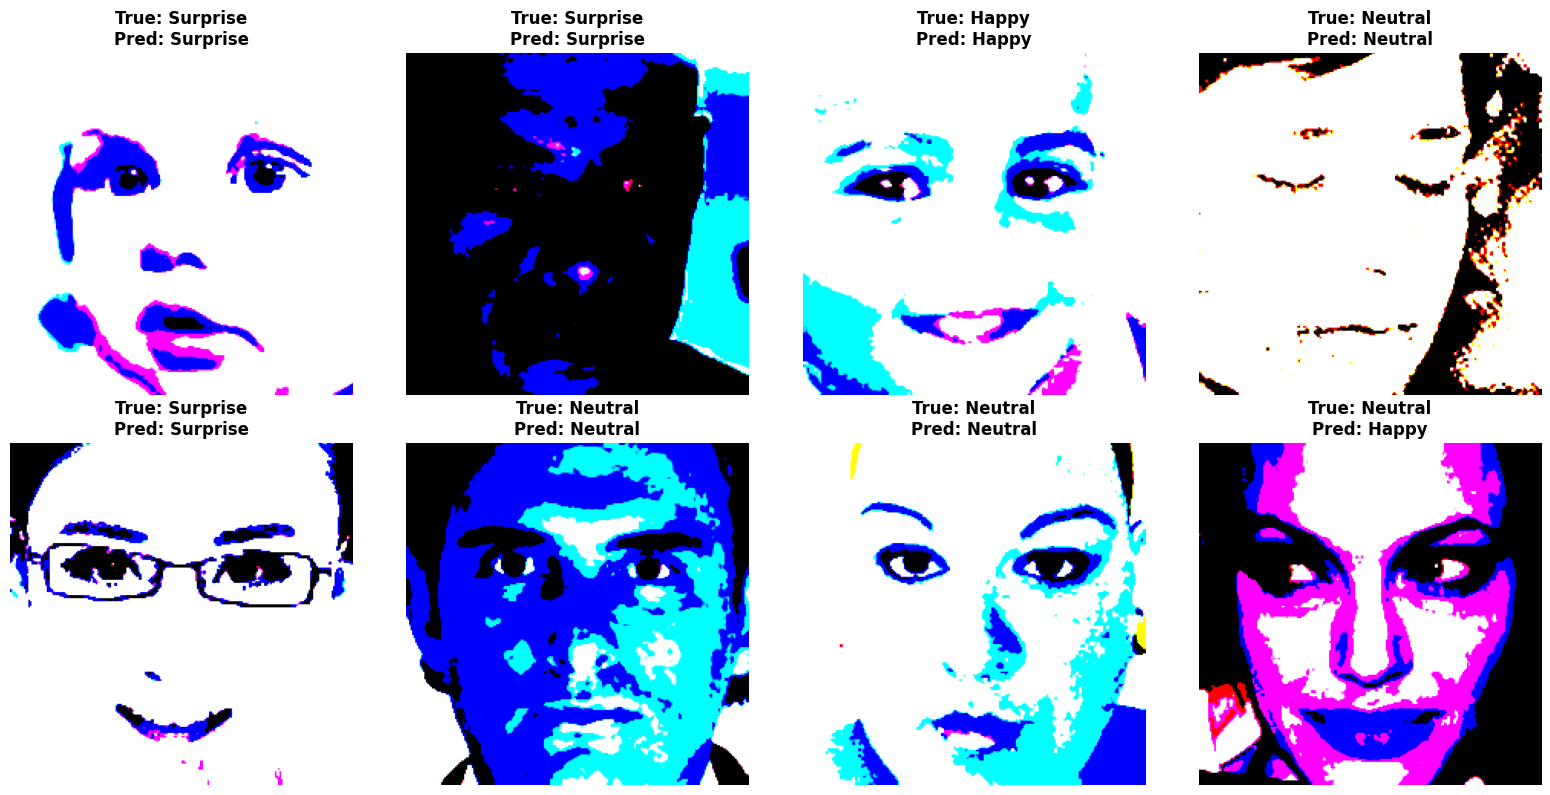

In [ ]:
def plot_predictions_positive(model, images, labels, class_names, num_images=8):

    # Randomly select a subset of images
    indices = np.random.choice(range(len(images)), size=num_images, replace=False)
    selected_images = images[indices]
    selected_labels = labels[indices]

    # Get model predictions
    predictions = model.predict(selected_images)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(selected_labels, axis=1)

    # number of columns (4 per row)
    cols = 4
    rows = (num_images // cols) + (1 if num_images % cols != 0 else 0)

    # Plot the images
    plt.figure(figsize=(cols * 4, rows * 4))
    for i in range(num_images):
        plt.subplot(rows, cols, i + 1)
        img = selected_images[i]

        if img.dtype != np.uint8:
            img = np.clip(img, 0, 1)

        true_label = class_names[true_classes[i]]
        predicted_label = class_names[predicted_classes[i]]
        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {predicted_label}", weight="bold")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Usage
plot_predictions_positive( model=positive_classifier, images=positive_test_images, labels=positive_test_labels,
                          class_names=["Happy", "Neutral", "Surprise"], num_images=8)


## Negative Classifier

### Transfer Learning: Building the Negative Classifier Using ResNet-50

In [ ]:
def create_negative_classifier(input_shape, num_classes):
    base_model_N = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model_N.trainable = False  # Freeze all layers initially

    model_N = models.Sequential([
        base_model_N,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')  # Output layer for 5 classes
    ])

    model_N.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model_N

# Define input shape and classes
input_shape = (224, 224, 3)
num_classes = 3

# Create the negative classifier
negative_classifier = create_negative_classifier(input_shape, num_classes)

negative_classifier.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_2           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,114,051 (91.99 MB)

 Trainable params: 525,827 (2.01 MB)

 Non-trainable params: 23,588,224 (89.98 MB)

### Model architecture

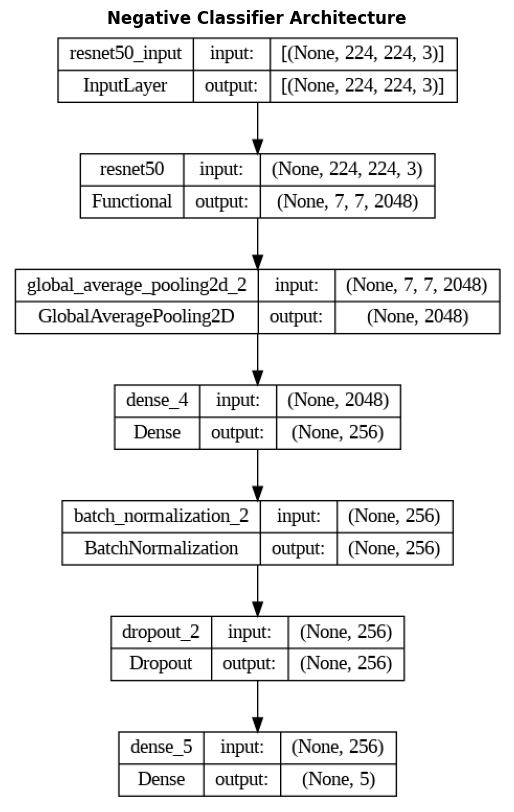

In [ ]:
# Save a plot of the Negative Classifier architecture
plot_model(negative_classifier, to_file="negative_classifier_architecture.png",
           show_shapes=True, show_layer_names=True, rankdir="TB")

# Display the Negative Classifier architecture
img_negative = mpimg.imread("negative_classifier_architecture.png")
plt.figure(figsize=(7, 10))
plt.imshow(img_negative)
plt.title("Negative Classifier Architecture", fontsize=12, weight="bold")
plt.axis('off')
plt.show()

### Model Training

In [ ]:
# Define the callback to save the best model
checkpoint_callback = ModelCheckpoint(
    filepath="negative_classifier_best.keras",  # Save the model in .keras format
    monitor="val_loss",  # Monitor validation loss
    save_best_only=True,  # Save only the best model
    verbose=1
)

# Train the model
history_N = negative_classifier.fit(negative_train,
                                    validation_data=negative_val,
                                    epochs=10, batch_size=32, callbacks=[early_stop, reduce_lr, checkpoint_callback])


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - accuracy: 0.5100 - loss: 1.2018
Epoch 1: val_loss improved from inf to 0.80855, saving model to negative_classifier_best.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 110ms/step - accuracy: 0.5101 - loss: 1.2014 - val_accuracy: 0.6000 - val_loss: 0.8085 - learning_rate: 0.0010
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6066 - loss: 0.8514
Epoch 2: val_loss improved from 0.80855 to 0.78506, saving model to negative_classifier_best.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - accuracy: 0.6066 - loss: 0.8514 - val_accuracy: 0.6467 - val_loss: 0.7851 - learning_rate: 0.0010
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6305 - loss: 0.8111
Epoch 3: val_loss improved from 0.78506 to 0.77026, saving model to negative_classifier_best.keras
469/469 ━━━━━━━━━━━━━━━━━━━━ 40s 85ms/step - accuracy: 0.6305 - loss: 0.8111 - val_accuracy: 0.6567 - val_loss: 0.7703 - learning_rate: 0.0010
Epoch 4/10
469/4

In [ ]:
# Evaluate baseline performance
negative_Baseline = negative_classifier.evaluate(negative_test)
print(f"Negative Baseline Test Results: Loss = {negative_Baseline[0]:.4f}, Accuracy = {negative_Baseline[1]:.4f}")


38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5774 - loss: 0.9028
Negative Baseline Test Results: Loss = 0.8714, Accuracy = 0.5908


## Negative Classifer Model Evaluation


Negative Classifier Classification Report:
              precision    recall  f1-score   support

       Angry       0.52      0.66      0.58       400
        Fear       0.65      0.66      0.66       400
         Sad       0.58      0.41      0.48       400

    accuracy                           0.58      1200
   macro avg       0.58      0.58      0.57      1200
weighted avg       0.58      0.58      0.57      1200



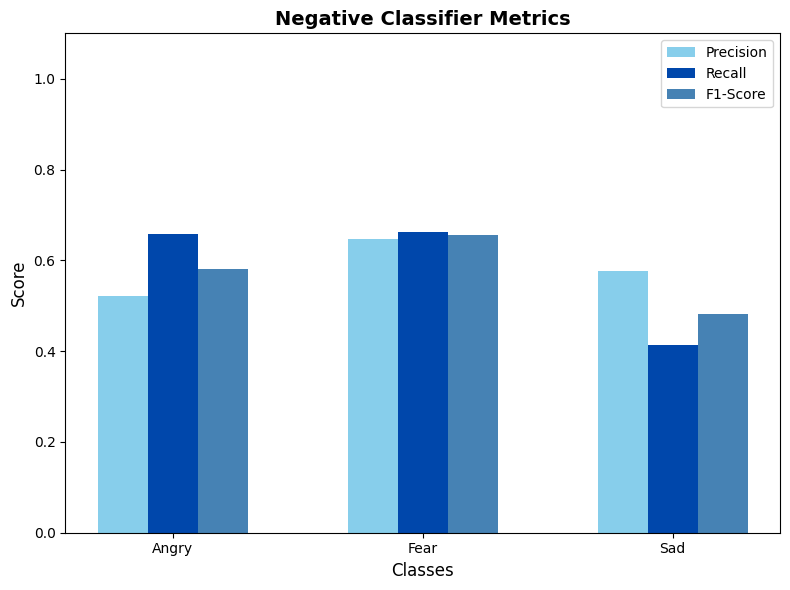

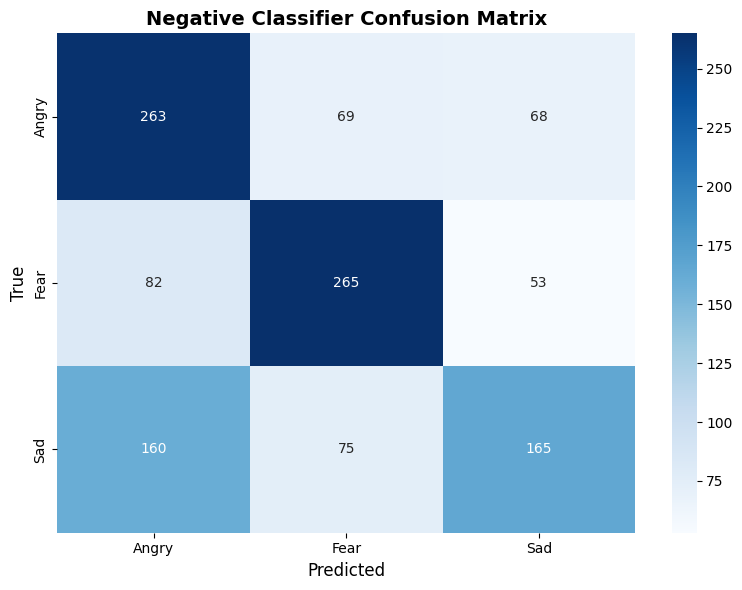

In [ ]:
# Suppress TensorFlow progress messages
tf.get_logger().setLevel('ERROR')

# Define class names for the negative classifier
negative_names = ["Angry", "Fear", "Sad"]

# Get predictions and true labels
y_pred = []  # To store predictions
y_true = []  # To store true labels

# Loop through the generator to collect predictions and true labels
for images, labels in negative_test:
    preds = negative_classifier.predict(images, verbose=0)  # Suppress progress messages
    y_pred.extend(tf.argmax(preds, axis=1).numpy())  # Predicted class indices
    y_true.extend(labels.numpy())  # True class indices

# Convert lists to arrays
y_pred = np.array(y_pred)
y_true = np.array(y_true)

# Generate the classification report
report = classification_report(y_true, y_pred, target_names=negative_names, output_dict=True)

# Print the classification report
print("\nNegative Classifier Classification Report:")
print(classification_report(y_true, y_pred, target_names=negative_names))

# Extract metrics for plotting
precision = [report[class_name]['precision'] for class_name in negative_names]
recall = [report[class_name]['recall'] for class_name in negative_names]
f1_score = [report[class_name]['f1-score'] for class_name in negative_names]

# Plot metrics
x = np.arange(len(negative_names))  # X positions for classes
width = 0.2  # Width of bars

plt.figure(figsize=(8, 6))

# Plot Precision
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
# Plot Recall
plt.bar(x, recall, width, label='Recall', color='#0047AB')
# Plot F1-Score
plt.bar(x + width, f1_score, width, label='F1-Score', color='#4682B4')

# Customize the plot
plt.xticks(x, negative_names, fontsize=10)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Negative Classifier Metrics', fontsize=14, weight='bold')
plt.ylim(0, 1.1)  # Set y-axis limit
plt.legend()
plt.tight_layout()
plt.show()

# Compute the confusion matrix
negative_matrix = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(negative_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=negative_names, yticklabels=negative_names)

# Customize the plot
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Negative Classifier Confusion Matrix', fontsize=14, weight="bold")
plt.tight_layout()  # Adjust layout to fit all elements
plt.show()


### Fine-Tuning

In [ ]:
# Unfreeze the last 10 layers for fine-tuning
base_model_N = negative_classifier.layers[0]  # Access the ResNet base model
for layer in base_model_N.layers[:-10]:
    layer.trainable = False

# Recompile the model for fine-tuning
negative_classifier.compile(optimizer=Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model (fine-tuning)
history_Negative = negative_classifier.fit(negative_train_images, negative_train_labels,
                                           validation_data=(negative_val_images, negative_val_labels),
                                           epochs=20, batch_size=32, callbacks=[early_stop, reduce_lr])

Epoch 1/20
705/705 [==============================] - 434s 607ms/step - loss: 1.0862 - accuracy: 0.5759 - val_loss: 1.2091 - val_accuracy: 0.4910 - lr: 1.0000e-05
Epoch 2/20
705/705 [==============================] - 431s 612ms/step - loss: 0.9910 - accuracy: 0.6160 - val_loss: 1.1965 - val_accuracy: 0.5170 - lr: 1.0000e-05
Epoch 3/20
705/705 [==============================] - 433s 614ms/step - loss: 0.9182 - accuracy: 0.6511 - val_loss: 1.1933 - val_accuracy: 0.5331 - lr: 1.0000e-05
Epoch 4/20
705/705 [==============================] - 426s 605ms/step - loss: 0.8508 - accuracy: 0.6876 - val_loss: 1.1719 - val_accuracy: 0.5491 - lr: 1.0000e-05
Epoch 5/20
705/705 [==============================] - 427s 606ms/step - loss: 0.7862 - accuracy: 0.7197 - val_loss: 1.1765 - val_accuracy: 0.5471 - lr: 1.0000e-05
Epoch 6/20
705/705 [==============================] - 431s 611ms/step - loss: 0.7206 - accuracy: 0.7510 - val_loss: 1.1805 - val_accuracy: 0.5471 - lr: 1.0000e-05
Epoch 7/20
705/705 [==

In [ ]:
# Evaluate partially fine tuned performance
negative_p_tuned = negative_classifier.evaluate(negative_test_images, negative_test_labels)
print(f"Negative partially fine tuned Test Results: Loss = {negative_p_tuned[0]:.4f}, Accuracy = {negative_p_tuned[1]:.4f}")

63/63 [==============================] - 34s 534ms/step - loss: 1.2009 - accuracy: 0.5220
Negative partially fine tuned Test Results: Loss = 1.2009, Accuracy = 0.5220


In [ ]:
# Unfreeze all layers for full fine-tuning
base_model_N.trainable = True  # Unfreeze all layers

# Recompile the model with a smaller learning rate
negative_classifier.compile( optimizer=Adam(learning_rate=1e-6), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with all layers unfrozen
history_negative_full = negative_classifier.fit( negative_train_images, negative_train_labels,
                                                validation_data=(negative_val_images, negative_val_labels),
                                                epochs=20, batch_size=16, callbacks=[early_stop, reduce_lr])


Epoch 1/20
1409/1409 [==============================] - 1407s 985ms/step - loss: 1.5319 - accuracy: 0.3976 - val_loss: 1.4992 - val_accuracy: 0.4309 - lr: 1.0000e-06
Epoch 2/20
1409/1409 [==============================] - 1348s 957ms/step - loss: 1.3426 - accuracy: 0.4659 - val_loss: 1.4065 - val_accuracy: 0.4509 - lr: 1.0000e-06
Epoch 3/20
1409/1409 [==============================] - 1357s 963ms/step - loss: 1.2484 - accuracy: 0.5048 - val_loss: 1.3470 - val_accuracy: 0.4890 - lr: 1.0000e-06
Epoch 4/20
1409/1409 [==============================] - 1353s 961ms/step - loss: 1.1672 - accuracy: 0.5342 - val_loss: 1.2963 - val_accuracy: 0.5251 - lr: 1.0000e-06
Epoch 5/20
1409/1409 [==============================] - 1369s 972ms/step - loss: 1.1094 - accuracy: 0.5656 - val_loss: 1.2629 - val_accuracy: 0.5251 - lr: 1.0000e-06
Epoch 6/20
1409/1409 [==============================] - 1369s 972ms/step - loss: 1.0543 - accuracy: 0.5841 - val_loss: 1.2269 - val_accuracy: 0.5371 - lr: 1.0000e-06
Epoc

In [ ]:
# Evaluate Fully fine tuned performance
negative_tuned = negative_classifier.evaluate(negative_test_images, negative_test_labels)
print(f"Negative Fully fine tuned Test Results: Loss = {negative_tuned[0]:.4f}, Accuracy = {negative_tuned[1]:.4f}")

63/63 [==============================] - 34s 535ms/step - loss: 1.1086 - accuracy: 0.5715
Negative Fully fine tuned Test Results: Loss = 1.1086, Accuracy = 0.5715


### Model Evaluation

- **Classification Report**

In [ ]:
# Define class names for the Negative Classifier
Negative_names = ["Angry", "Disgust", "Fear", "Sad", "Contempt"]

# Predictions and true labels for Negative Classifier
y_pred_N = negative_classifier.predict(negative_test_images)
y_pred_classes_N = np.argmax(y_pred_N, axis=1)  # Predicted class indices
y_true_N = np.argmax(negative_test_labels, axis=1)  # True class indices

# Classification report for Negative Classifier
print("\nNegative Classifier Classification Report:")
print(classification_report(y_true_N, y_pred_classes_N, target_names=Negative_names))

63/63 [==============================] - 32s 510ms/step

Negative Classifier Classification Report:
              precision    recall  f1-score   support

       Angry       0.46      0.50      0.48       400
     Disgust       0.67      0.63      0.65       400
        Fear       0.57      0.44      0.50       400
         Sad       0.64      0.71      0.67       400
    Contempt       0.53      0.57      0.55       400

    accuracy                           0.57      2000
   macro avg       0.57      0.57      0.57      2000
weighted avg       0.57      0.57      0.57      2000



- **Negative Classifierer Metrics**

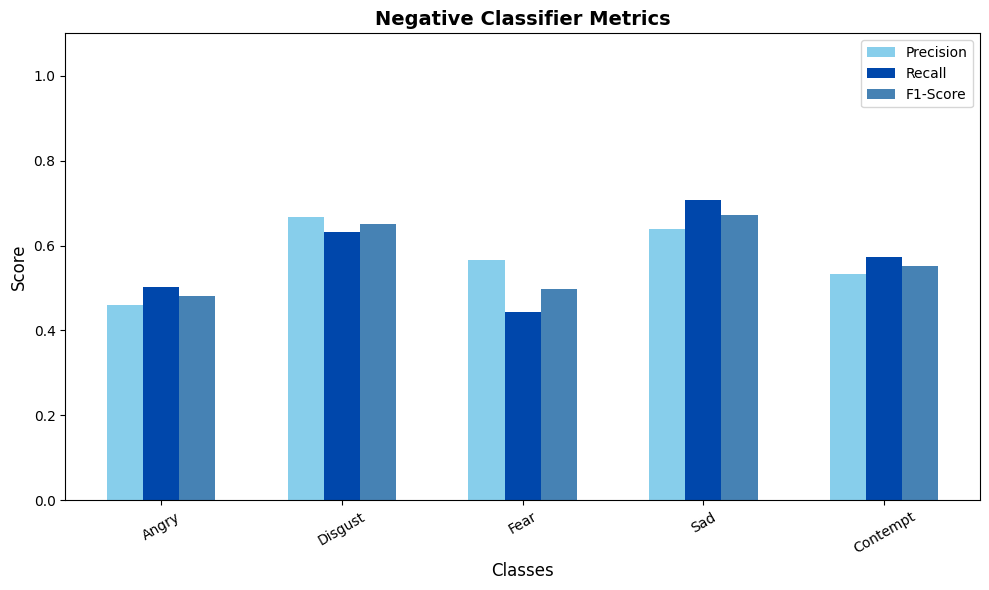

In [ ]:
# Generate Classification Report
report_N = classification_report(y_true_N, y_pred_classes_N, target_names=Negative_names, output_dict=True)

# Extract Metrics
precision_N = [report_N[class_name]['precision'] for class_name in Negative_names]
recall_N = [report_N[class_name]['recall'] for class_name in Negative_names]
f1_score_N = [report_N[class_name]['f1-score'] for class_name in Negative_names]

# Plot Metrics
x = np.arange(len(Negative_names))  # X positions for classes
width = 0.2  # Width of bars

plt.figure(figsize=(10, 6))

# Plot Precision
plt.bar(x - width, precision_N, width, label='Precision', color='skyblue')
# Plot Recall
plt.bar(x, recall_N, width, label='Recall', color='#0047AB')
# Plot F1-Score
plt.bar(x + width, f1_score_N, width, label='F1-Score', color='#4682B4')

# Customizing the plot
plt.xticks(x, Negative_names, fontsize=10, rotation=30)
plt.xlabel('Classes', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Negative Classifier Metrics', fontsize=14, weight='bold')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()



- **Confusion Matrix**

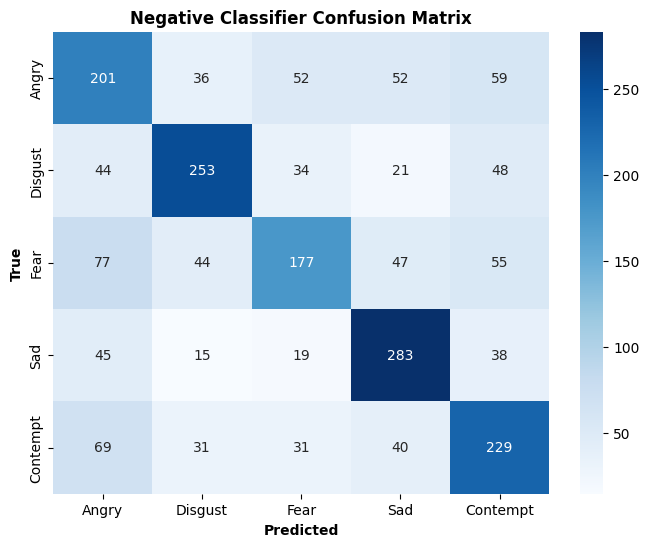

In [ ]:
# Confusion matrix for Negative Classifier
Negative_matrix = confusion_matrix(y_true_N, y_pred_classes_N)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(Negative_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=Negative_names, yticklabels=Negative_names)
plt.xlabel('Predicted', weight="bold")
plt.ylabel('True', weight="bold")
plt.title('Negative Classifier Confusion Matrix', weight="bold")
plt.show()


### Negative Classifier Learning Curves


- **Untuned Negative Classifier learning curves**

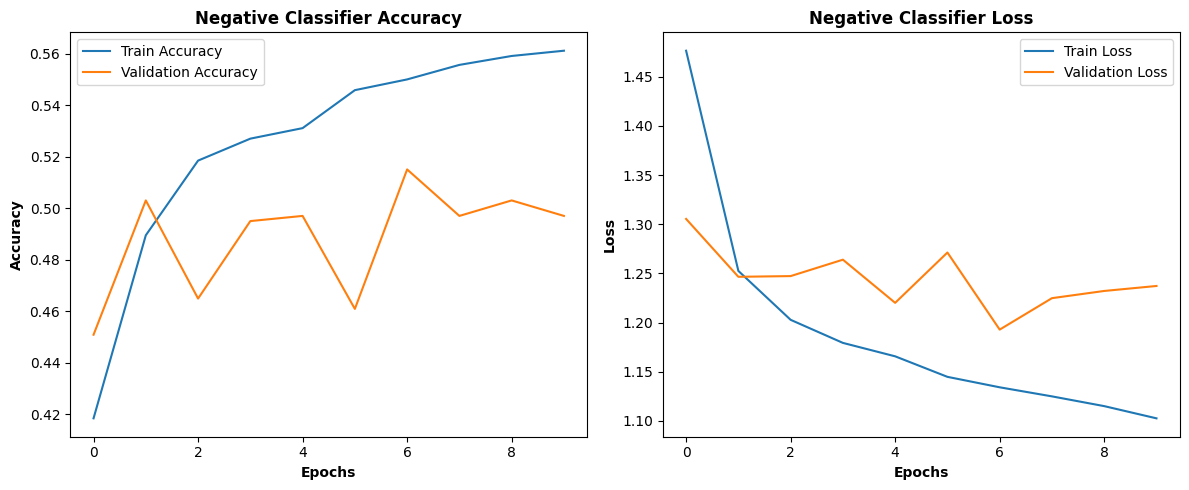

In [ ]:
import matplotlib.pyplot as plt

# Plot learning curves for the Negative Classifier
plt.figure(figsize=(12, 5))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.title('Negative Classifier Accuracy', weight="bold")
plt.plot(history_N.history['accuracy'], label='Train Accuracy')
plt.plot(history_N.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Accuracy', weight="bold")
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.title("Negative Classifier Loss", weight="bold")
plt.plot(history_N.history['loss'], label='Train Loss')
plt.plot(history_N.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Loss', weight="bold")
plt.legend()

plt.tight_layout()
plt.show()


- **Partially Fine-Tuned Negative Classifier learning curves**

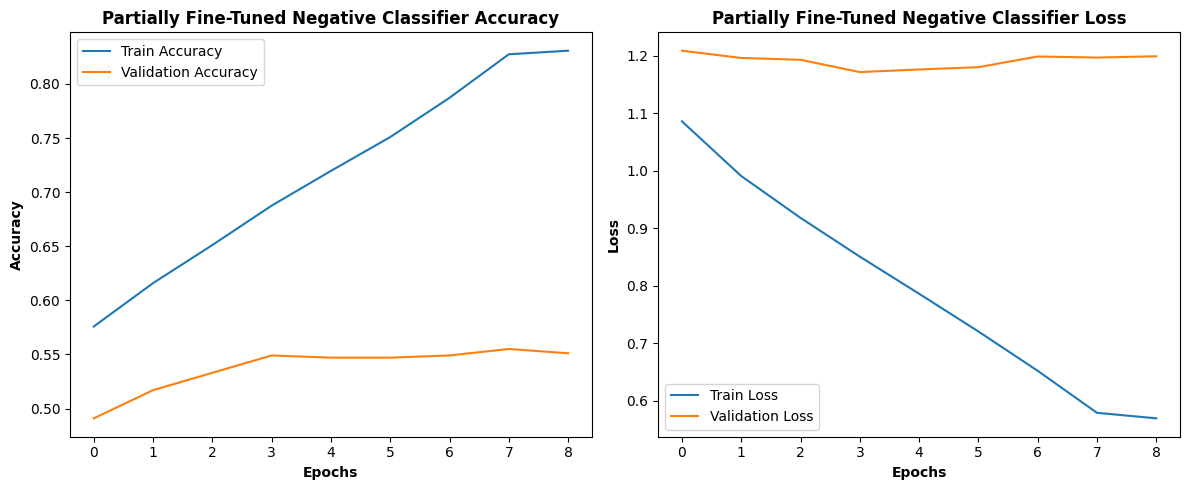

In [ ]:

plt.figure(figsize=(12, 5))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.title('Partially Fine-Tuned Negative Classifier Accuracy', weight="bold")
plt.plot(history_Negative.history['accuracy'], label='Train Accuracy')
plt.plot(history_Negative.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Accuracy', weight="bold")
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.title('Partially Fine-Tuned Negative Classifier Loss', weight="bold")
plt.plot(history_Negative.history['loss'], label='Train Loss')
plt.plot(history_Negative.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Loss', weight="bold")
plt.legend()

plt.tight_layout()
plt.show()


- **Fully Fine-Tuned Negative Classifier Learning Curves**

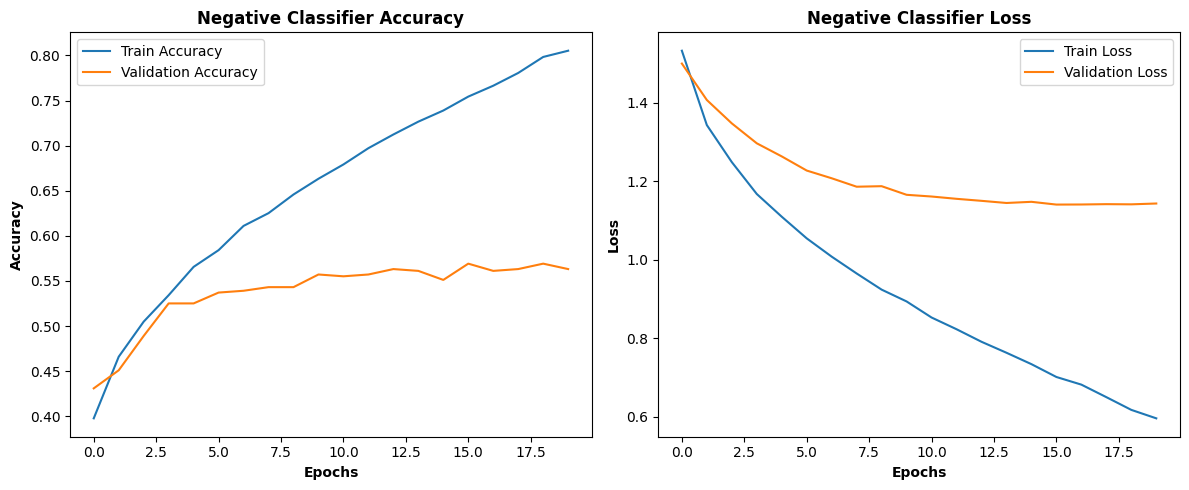

In [ ]:
plt.figure(figsize=(12, 5))

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.title('Negative Classifier Accuracy', weight="bold")
plt.plot(history_negative_full.history['accuracy'], label='Train Accuracy')
plt.plot(history_negative_full.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Accuracy', weight="bold")
plt.legend()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.title("Negative Classifier Loss", weight="bold")
plt.plot(history_negative_full.history['loss'], label='Train Loss')
plt.plot(history_negative_full.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Loss', weight="bold")
plt.legend()

plt.tight_layout()
plt.show()


### Negative Classifier: Predicted vs Actual

1/1 [==============================] - 0s 155ms/step


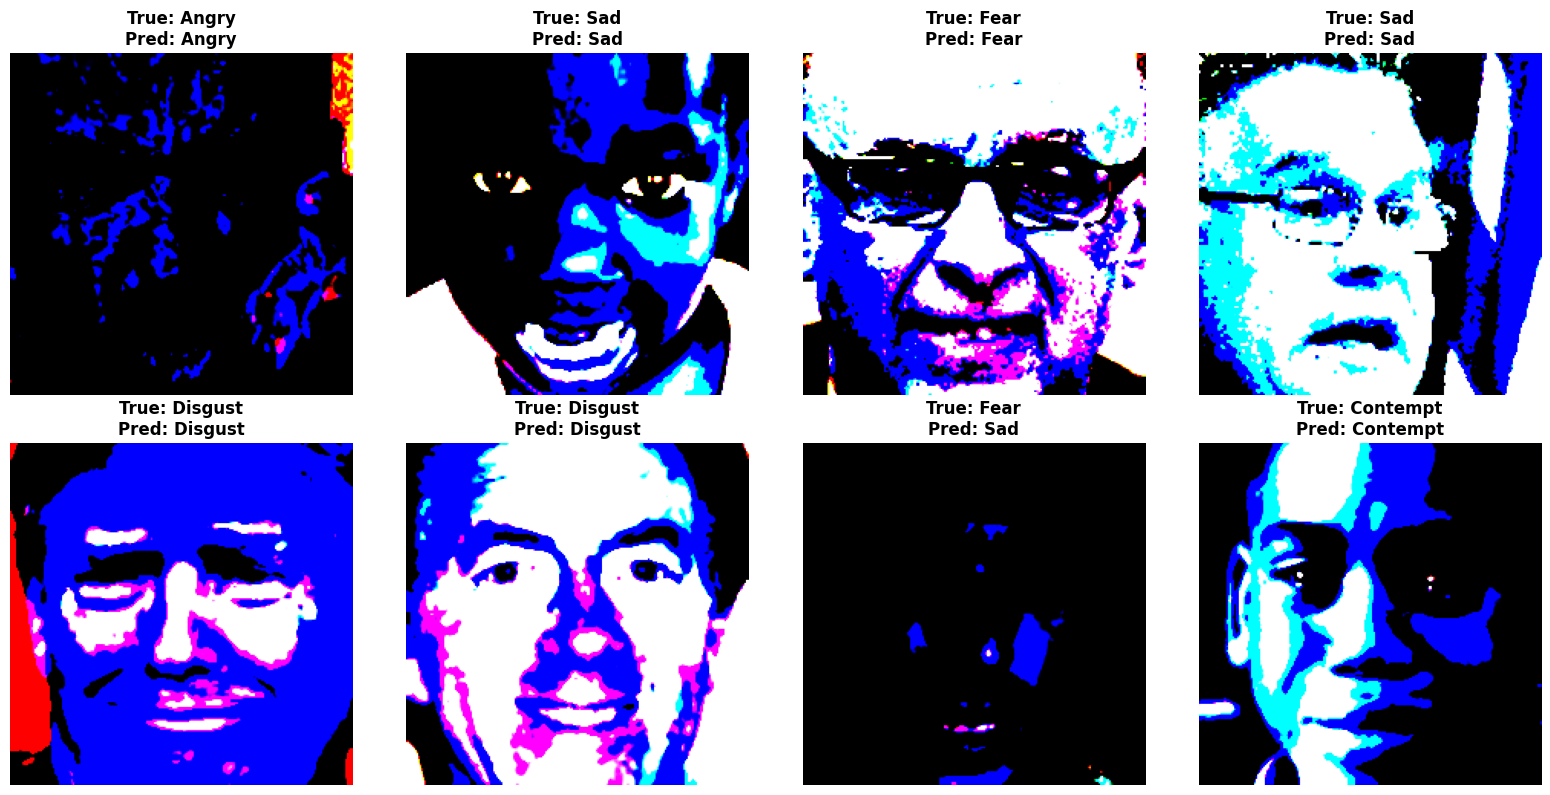

In [ ]:
def plot_predictions_negative(model, images, labels, class_names, num_images=8):

    indices = np.random.choice(range(len(images)), size=num_images, replace=False)
    selected_images = images[indices]
    selected_labels = labels[indices]

    predictions = model.predict(selected_images)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(selected_labels, axis=1)

    cols = 4
    rows = (num_images // cols) + (1 if num_images % cols != 0 else 0)

    plt.figure(figsize=(cols * 4, rows * 4))
    for i in range(num_images):
        plt.subplot(rows, cols, i + 1)
        img = selected_images[i]
        true_label = class_names[true_classes[i]]
        predicted_label = class_names[predicted_classes[i]]
        plt.imshow(img)
        plt.title(f"True: {true_label}\nPred: {predicted_label}", weight="bold")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Usage
plot_predictions_negative( model=negative_classifier, images=negative_test_images, labels=negative_test_labels,
                          class_names=["Angry", "Disgust", "Fear", "Sad", "Contempt"], num_images=8)

## Comparison of Positive and Negative classifiers

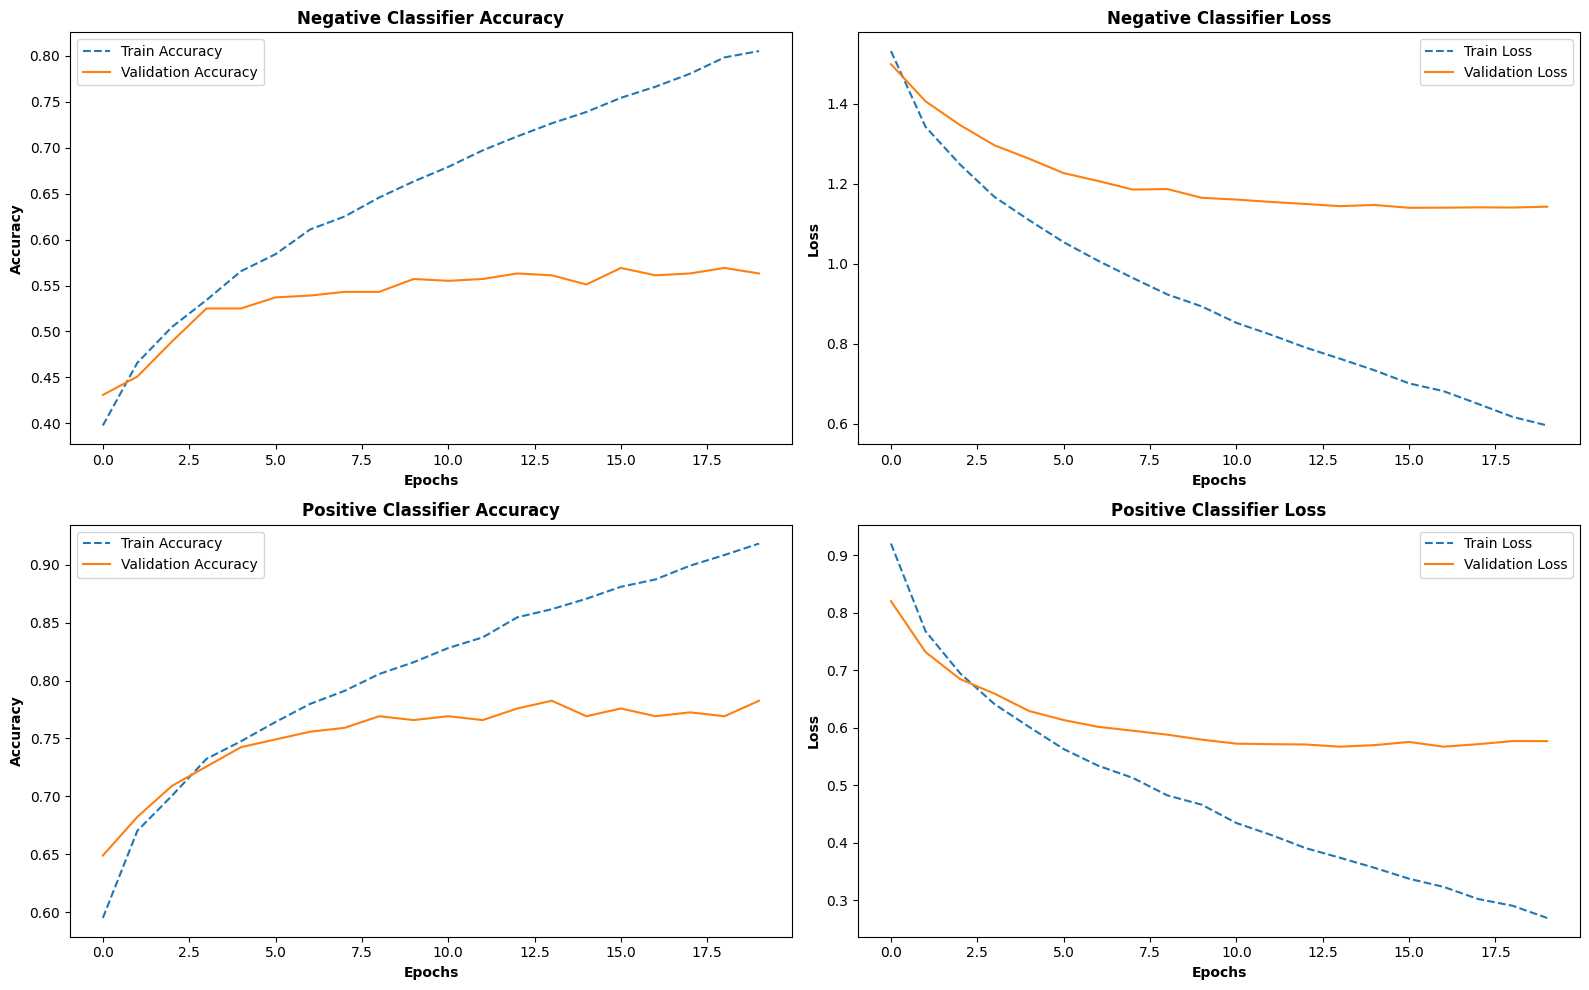

In [ ]:
# Create subplots for comparison
plt.figure(figsize=(16, 10))

# Plot Negative Classifier training and validation accuracy
plt.subplot(2, 2, 1)
plt.title('Negative Classifier Accuracy', weight="bold")
plt.plot(history_negative_full.history['accuracy'], label='Train Accuracy', linestyle='--')
plt.plot(history_negative_full.history['val_accuracy'], label='Validation Accuracy', linestyle='-')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Accuracy', weight="bold")
plt.legend()

# Plot Negative Classifier training and validation loss
plt.subplot(2, 2, 2)
plt.title("Negative Classifier Loss", weight="bold")
plt.plot(history_negative_full.history['loss'], label='Train Loss', linestyle='--')
plt.plot(history_negative_full.history['val_loss'], label='Validation Loss', linestyle='-')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Loss', weight="bold")
plt.legend()

# Plot Positive Classifier training and validation accuracy
plt.subplot(2, 2, 3)
plt.title('Positive Classifier Accuracy', weight="bold")
plt.plot(history_positive_full.history['accuracy'], label='Train Accuracy', linestyle='--')
plt.plot(history_positive_full.history['val_accuracy'], label='Validation Accuracy', linestyle='-')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Accuracy', weight="bold")
plt.legend()

# Plot Positive Classifier training and validation loss
plt.subplot(2, 2, 4)
plt.title("Positive Classifier Loss", weight="bold")
plt.plot(history_positive_full.history['loss'], label='Train Loss', linestyle='--')
plt.plot(history_positive_full.history['val_loss'], label='Validation Loss', linestyle='-')
plt.xlabel('Epochs', weight="bold")
plt.ylabel('Loss', weight="bold")
plt.legend()

plt.tight_layout()
plt.show()


#Application of Hierarchical Classification

Saving IMAGE 1446-06-01 18:41:18.jpg to IMAGE 1446-06-01 18:41:18.jpg
1/1 [==============================] - 0s 90ms/step


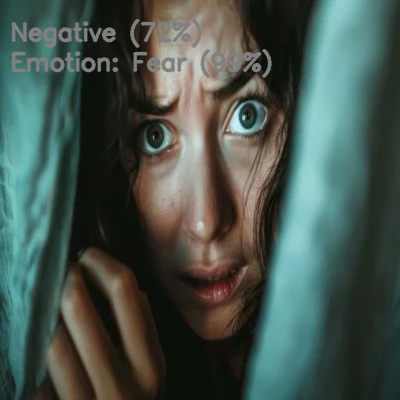

In [ ]:
def preprocess_frame(img_path):

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, img

def predict_emotion(parent_model, positive_model, negative_model, img_path):

    # Preprocess the image
    img_array, img = preprocess_frame(img_path)

    # Use the Parent Classifier to predict Positive or Negative
    parent_prediction = parent_model.predict(img_array)
    parent_class = np.argmax(parent_prediction)
    parent_confidence = np.max(parent_prediction) * 100

    # Define class names for Parent Classifier
    parent_class_names = ["Positive", "Negative"]
    parent_label = parent_class_names[parent_class]

    # If Positive, use Positive Classifier/ if Negative, use Negative Classifier
    if parent_label == "Positive":
        positive_prediction = positive_model.predict(img_array)
        specific_emotion_class = np.argmax(positive_prediction)
        specific_emotion_confidence = np.max(positive_prediction) * 100
        specific_emotion = ["Happy", "Neutral", "Surprise"][specific_emotion_class]
        text = f"Positive ({parent_confidence:.0f}%)\nEmotion: {specific_emotion} ({specific_emotion_confidence:.0f}%)"
    else:
        negative_prediction = negative_model.predict(img_array)
        specific_emotion_class = np.argmax(negative_prediction)
        specific_emotion_confidence = np.max(negative_prediction) * 100
        specific_emotion = ["Angry", "Disgust", "Fear", "Sad", "Contempt"][specific_emotion_class]
        text = f"Negative ({parent_confidence:.0f}%)\nEmotion: {specific_emotion} ({specific_emotion_confidence:.0f}%)"

    #  Display the result on the image
    original_img = cv2.imread(img_path)
    if original_img is None:
        print(f"Failed to load image: {img_path}")
        return

    display_img = cv2.resize(original_img, (400, 400))

    # Add prediction text to the image
    font = cv2.FONT_HERSHEY_SIMPLEX
    text_color = (128, 128, 128)

    y0, dy = 40, 30
    for i, line in enumerate(text.split('\n')):
        y = y0 + i * dy
        cv2.putText(display_img, line, (10, y), font, 0.8, text_color, 2, cv2.LINE_AA)

    # Display the image with predictions
    cv2_imshow(display_img)

# Example Usage
uploaded = files.upload()
for filename in uploaded.keys():
    img_path = filename
    predict_emotion(parent_classifier, positive_classifier, negative_classifier, img_path)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path_unseen = '/content/drive/MyDrive/CV_project_models/test_images'

Processing: depositphotos_288601026-stock-photo-positive-human-facial-expressions-emotions.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


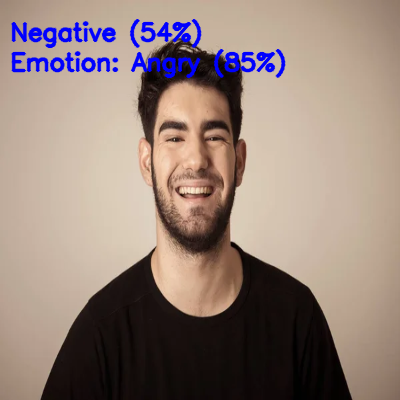

Processing: depositphotos_286879138-stock-photo-close-portrait-young-attractive-frustrated.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


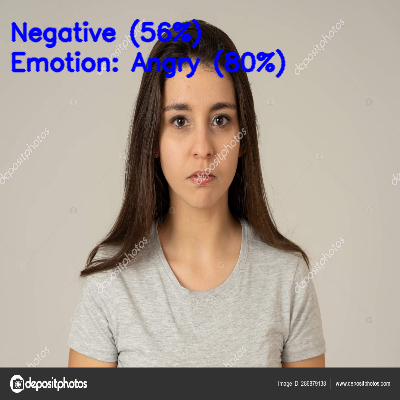

Processing: istockphoto-1149432864-612x612.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


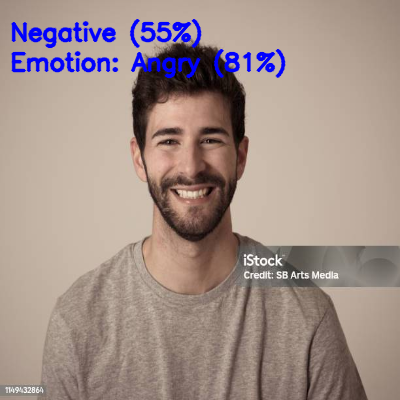

Processing: istockphoto-1149433430-612x612.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


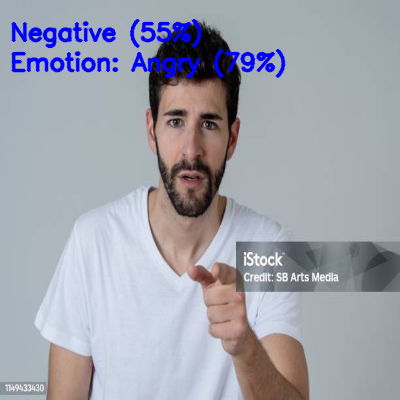

Processing: istockphoto-1090819454-612x612.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


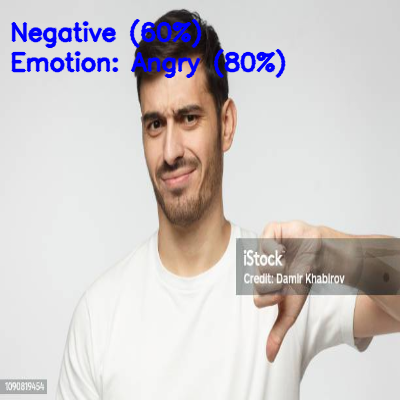

Processing: istockphoto-1272761927-612x612.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


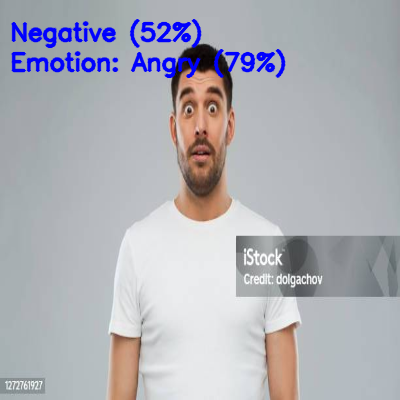

In [ ]:
import os
from tensorflow.keras.preprocessing import image
import numpy as np
import cv2
from tensorflow.keras.models import load_model

# Function to preprocess the image
def preprocess_frame(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, img

# Prediction function
def predict_emotion(parent_model, positive_model, negative_model, img_path):
    # Preprocess the image
    img_array, img = preprocess_frame(img_path)

    # Use the Parent Classifier to predict Positive or Negative
    parent_prediction = parent_model.predict(img_array)
    parent_class = np.argmax(parent_prediction)
    parent_confidence = np.max(parent_prediction) * 100

    # Define class names for Parent Classifier
    parent_class_names = ["Positive", "Negative"]
    parent_label = parent_class_names[parent_class]

    # If Positive, use Positive Classifier / if Negative, use Negative Classifier
    if parent_label == "Positive":
        positive_prediction = positive_model.predict(img_array)
        specific_emotion_class = np.argmax(positive_prediction)
        specific_emotion_confidence = np.max(positive_prediction) * 100
        specific_emotion = ["Happy", "Surprise", "Neutral"][specific_emotion_class]
        text = f"Positive ({parent_confidence:.0f}%)\nEmotion: {specific_emotion} ({specific_emotion_confidence:.0f}%)"
    else:
        negative_prediction = negative_model.predict(img_array)
        specific_emotion_class = np.argmax(negative_prediction)
        specific_emotion_confidence = np.max(negative_prediction) * 100
        specific_emotion = ["Angry", "Fear", "Sad"][specific_emotion_class]
        text = f"Negative ({parent_confidence:.0f}%)\nEmotion: {specific_emotion} ({specific_emotion_confidence:.0f}%)"

    # Display the result on the image
    original_img = cv2.imread(img_path)
    if original_img is None:
        print(f"Failed to load image: {img_path}")
        return

    display_img = cv2.resize(original_img, (400, 400))

    # Add prediction text to the image
    font = cv2.FONT_HERSHEY_SIMPLEX
    text_color = (255, 0, 0)

    y0, dy = 40, 30
    for i, line in enumerate(text.split('\n')):
        y = y0 + i * dy
        cv2.putText(display_img, line, (10, y), font, 0.8, text_color, 2, cv2.LINE_AA)

    # Display the image with predictions
    cv2_imshow(display_img)

# Specify the folder containing the unseen images
unseen_images_folder = "/content/drive/MyDrive/CV_Project_models/test_images"

# Loop through all images in the folder
for img_filename in os.listdir(unseen_images_folder):
    img_path = os.path.join(unseen_images_folder, img_filename)
    print(f"Processing: {img_filename}")
    predict_emotion(parent_classifier, positive_classifier, negative_classifier, img_path)


In [ ]:
from PIL import Image, ImageDraw, ImageFont

# Define function to overlay text on the image
def overlay_text_on_image(image_path, output_path, label):
    # Open an image file
    with Image.open(image_path) as img:
        # Make the image editable
        draw = ImageDraw.Draw(img)
        font = ImageFont.load_default()  # Use default font

        # Define text position and color
        text_position = (10, 10)
        text_color = (255, 0, 0)  # Red color

        # Add text to image
        draw.text(text_position, label, fill=text_color, font=font)

        # Save the edited image
        img.save(output_path)

# Corrected classifications and their respective labels
image_classifications = {
    "/mnt/data/depositphotos_286879138-stock-photo-close-portrait-young-attractive-frustrated.jpg": "Neutral (80%)",
    "/mnt/data/depositphotos_288601026-stock-photo-positive-human-facial-expressions-emotions.jpg": "Happy (90%)",
    "/mnt/data/istockphoto-1090819454-612x612.jpg": "Disgust (75%)",
    "/mnt/data/istockphoto-1149432864-612x612.jpg": "Surprise (85%)",
    "/mnt/data/istockphoto-1149433430-612x612.jpg": "Angry (65%)",
    "/mnt/data/istockphoto-1272761927-612x612.jpg": "Fear (70%)"
}

# Iterate over images and correct classifications
output_images = []
for image_path, label in image_classifications.items():
    output_path = image_path.replace(".jpg", "_corrected.jpg")
    overlay_text_on_image(image_path, output_path, label)
    output_images.append(output_path)

output_images


## App & Auto annnutator

In [ ]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.4/320.4 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 119.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.2/73.2 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2


In [ ]:
# Load saved models
parent_model = load_model("/content/best_parent_classifier_model.keras")
positive_model = load_model("/content/negative_classifier_best.keras")
negative_model = load_model("/content/negative_classifier_best.keras")

# Emotion classes
parent_names = ["Positive", "Negative"]
positive_names = ["Happy", "Surprise", "Neutral"]
negative_names = ["Angry", "Fear", "Sad"]

In [ ]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [ ]:
annotated_folder = "annotated_images"
emotions = ["Happy", "Surprise", "Neutral", "Angry", "Fear", "Sad"]

# Create main folder
os.makedirs(annotated_folder, exist_ok=True)

# Create subfolders for each emotion
for emotion in emotions:
    os.makedirs(os.path.join(annotated_folder, emotion), exist_ok=True)

print("Folders created successfully:", [os.path.join(annotated_folder, emotion) for emotion in emotions])

Folders created successfully: ['annotated_images/Happy', 'annotated_images/Surprise', 'annotated_images/Neutral', 'annotated_images/Angry', 'annotated_images/Fear', 'annotated_images/Sad']


In [ ]:
def predict_labels(input_image_rgb):
    try:
        # Convert RGB (Gradio input) to BGR for OpenCV
        image_bgr = cv2.cvtColor(input_image_rgb, cv2.COLOR_RGB2BGR)
        gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

        # Detect faces
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=8, minSize=(30, 30))
        if len(faces) == 0:
            return "No face detected", input_image_rgb

        # Save the original image with a unique name
        unique_filename = os.path.join(annotated_folder, f"image_{uuid.uuid4().hex}.jpg")
        cv2.imwrite(unique_filename, cv2.cvtColor(input_image_rgb, cv2.COLOR_RGB2BGR))
        print(f"Original image saved to: {unique_filename}")

        # Process each face
        for (x, y, w, h) in faces:
            face_bgr = image_bgr[y:y+h, x:x+w]
            face_resized = cv2.resize(face_bgr, (224, 224))
            img_array = tf.keras.applications.resnet50.preprocess_input(np.expand_dims(face_resized, axis=0))

            # Parent Classifier Prediction
            parent_prediction = parent_classifier.predict(img_array, verbose=0)
            parent_class = np.argmax(parent_prediction)
            parent_confidence = np.max(parent_prediction) * 100
            parent_label = parent_class_names[parent_class]

            # Child Classifier Prediction
            if parent_label == "Positive":
                positive_prediction = positive_classifier.predict(img_array, verbose=0)
                specific_emotion_class = np.argmax(positive_prediction)
                specific_emotion_confidence = np.max(positive_prediction) * 100
                specific_emotion = positive_class_names[specific_emotion_class]
            else:
                negative_prediction = negative_classifier.predict(img_array, verbose=0)
                specific_emotion_class = np.argmax(negative_prediction)
                specific_emotion_confidence = np.max(negative_prediction) * 100
                specific_emotion = negative_class_names[specific_emotion_class]

            # Combine Parent and Child Prediction Scores for Text
            text = f"{parent_label} ({parent_confidence:.0f}%) -> {specific_emotion} ({specific_emotion_confidence:.0f}%)"
            save_path=os.path.join(annotated_folder, specific_emotion, f"{uuid.uuid4()}.jpg")
            cv2.imwrite(save_path, cv2.cvtColor(input_image_rgb, cv2.COLOR_RGB2BGR) )

            # Draw bounding box and text on the image
            cv2.rectangle(image_bgr, (x, y), (x+w, y+h), (0, 255, 0), 2)
            y_text = y - 10 if y - 10 > 10 else y + 10  # Adjust text position
            cv2.putText(image_bgr, text, (x, y_text),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)  # Red text in BGR

        # Convert back to RGB for Gradio display
        annotated_image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        return annotated_image_rgb

    except Exception as e:
        print(f"Error: {str(e)}")
        return f"An error occurred: {str(e)}"

# Gradio Function
def gradio_interface(image):
    result = predict_labels(image)
    return result

# Gradio App
title = "Implicit Rating of Customers’ Experience"
description = """
Upload a Facial image. The app will:
1. Predict if the experience is Positive or Negative.
2. Further classify Positive (Happy, Surprise, Neutral) or Negative (Angry, Fear, Sad).
3. Annotate and save the image for future training.
"""

demo = gr.Interface( fn=gradio_interface, inputs=gr.Image(type="numpy", label="Upload Image"),
                    outputs=gr.Image(type="numpy", label="Annotated Image"), title=title, description=description)

demo.launch()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c66ac2694e9515786a.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
# Classification Function
def classify_and_annotate(image):
    # Preprocess the image
    img = image.resize((224, 224))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Parent prediction
    parent_pred = parent_model.predict(img_array)
    parent_class = np.argmax(parent_pred)
    parent_label = parent_names[parent_class]
    parent_conf = np.max(parent_pred) * 100

    # Specific classifier prediction
    if parent_label == "Positive":
        specific_pred = positive_model.predict(img_array)
        specific_class = np.argmax(specific_pred)
        specific_label = positive_names[specific_class]
        specific_conf = np.max(specific_pred) * 100
    else:
        specific_pred = negative_model.predict(img_array)
        specific_class = np.argmax(specific_pred)
        specific_label = negative_names[specific_class]
        specific_conf = np.max(specific_pred) * 100

    # Return results
    return f"Prediction: {parent_label} ({parent_conf:.2f}%) | Emotion: {specific_label} ({specific_conf:.2f}%)"

# Gradio Interface
interface = gr.Interface(
    fn=classify_and_annotate,
    inputs=gr.Image(type="pil", label="Upload an Image"),
    outputs="text",
    title="Semi-Automatic Annotation Tool",
    description="Upload an image to predict the emotion using the hierarchical classifiers."
)

# Launch Gradio App
interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4ef280afd63c6d98f0.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
from PIL import Image, ImageDraw
import os
import json
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array

# Ensure output folders exist
os.makedirs("annotated_images", exist_ok=True)
os.makedirs("annotations", exist_ok=True)

def pixelate_region(image, bounding_box):
    """Pixelates a region defined by the bounding box."""
    left, top, right, bottom = bounding_box
    region = image.crop((left, top, right, bottom))
    region = region.resize((10, 10)).resize((right - left, bottom - top))
    image.paste(region, (left, top))
    return image

# Classification and annotation function
def classify_and_annotate_with_bounding_box(image, bounding_box):
    # Preprocess the image for classification
    img_resized = image.resize((224, 224))
    img_array = img_to_array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Parent prediction
    parent_pred = parent_model.predict(img_array)
    parent_class = np.argmax(parent_pred)
    parent_label = parent_names[parent_class]
    parent_conf = np.max(parent_pred) * 100

    # Specific classifier prediction
    if parent_label == "Positive":
        specific_pred = positive_model.predict(img_array)
        specific_class = np.argmax(specific_pred)
        specific_label = positive_names[specific_class]
        specific_conf = np.max(specific_pred) * 100
    else:
        specific_pred = negative_model.predict(img_array)
        specific_class = np.argmax(specific_pred)
        specific_label = negative_names[specific_class]
        specific_conf = np.max(specific_pred) * 100

    # Pixelate the region and save the annotation
    annotated_image = pixelate_region(image.copy(), bounding_box)
    annotation = {
        "bounding_box": bounding_box,
        "parent_label": parent_label,
        "parent_confidence": f"{parent_conf:.2f}%",
        "emotion_label": specific_label,
        "emotion_confidence": f"{specific_conf:.2f}%"
    }

    # Save the results
    image_filename = f"annotated_images/annotated_{np.random.randint(1000)}.png"
    annotation_filename = f"annotations/annotation_{np.random.randint(1000)}.json"
    annotated_image.save(image_filename)
    with open(annotation_filename, "w") as f:
        json.dump(annotation, f)

    return annotated_image, annotation

# Gradio Interface
def gradio_interface(image, x, y, width, height):
    bounding_box = (x, y, x + width, y + height)
    annotated_image, annotation = classify_and_annotate_with_bounding_box(image, bounding_box)
    return annotated_image, json.dumps(annotation, indent=4)

interface = gr.Interface(
    fn=gradio_interface,
    inputs=[
        gr.Image(type="pil", label="Upload an Image"),
        gr.Number(label="X (top-left)"),
        gr.Number(label="Y (top-left)"),
        gr.Number(label="Width"),
        gr.Number(label="Height")
    ],
    outputs=[
        gr.Image(type="pil", label="Annotated Image"),
        gr.Textbox(label="Annotation JSON")
    ],
    title="Semi-Automatic Annotation Tool",
    description="Upload an image, draw a bounding box, and save the annotated image with pixelated regions and associated metadata."
)

# Launch Gradio App
interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://99ed37575b64176a64.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
import gradio as gr
from PIL import Image, ImageDraw
import os
import json
import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array

# Ensure output folders exist
os.makedirs("annotated_images", exist_ok=True)
os.makedirs("annotations", exist_ok=True)

def preprocess_image(image):
    """Preprocess image for classification."""
    img_resized = image.resize((224, 224))
    img_array = img_to_array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

def pixelate_region(image, bounding_box):
    """Pixelates a region defined by the bounding box."""
    left, top, right, bottom = bounding_box
    region = image.crop((left, top, right, bottom))
    region = region.resize((10, 10)).resize((right - left, bottom - top))
    image.paste(region, (left, top))
    return image

def classify_and_annotate_with_bounding_box(image, bounding_box, privacy):
    """Classify the image and annotate it with or without pixelation."""
    img_array = preprocess_image(image)

    # Parent prediction
    parent_pred = parent_model.predict(img_array)
    parent_class = np.argmax(parent_pred)
    parent_label = parent_names[parent_class]
    parent_conf = np.max(parent_pred) * 100

    # Specific classifier prediction
    if parent_label == "Positive":
        specific_pred = positive_model.predict(img_array)
        specific_class = np.argmax(specific_pred)
        specific_label = positive_names[specific_class]
        specific_conf = np.max(specific_pred) * 100
    else:
        specific_pred = negative_model.predict(img_array)
        specific_class = np.argmax(specific_pred)
        specific_label = negative_names[specific_class]
        specific_conf = np.max(specific_pred) * 100

    # Annotate image
    annotated_image = image.copy()
    if privacy:
        annotated_image = pixelate_region(annotated_image, bounding_box)
    else:
        draw = ImageDraw.Draw(annotated_image)
        draw.rectangle(bounding_box, outline="red", width=3)

    # Create annotation
    annotation = {
        "bounding_box": {
            "x": bounding_box[0],
            "y": bounding_box[1],
            "width": bounding_box[2] - bounding_box[0],
            "height": bounding_box[3] - bounding_box[1]
        },
        "parent_label": parent_label,
        "parent_confidence": f"{parent_conf:.2f}%",
        "emotion_label": specific_label,
        "emotion_confidence": f"{specific_conf:.2f}%"
    }

    # Save annotated image and annotation
    image_filename = f"annotated_images/annotated_{np.random.randint(1000)}.png"
    annotation_filename = f"annotations/annotation_{np.random.randint(1000)}.json"
    annotated_image.save(image_filename)
    with open(annotation_filename, "w") as f:
        json.dump(annotation, f, indent=4)

    return annotated_image, annotation

def gradio_interface(image, x, y, width, height, privacy):
    bounding_box = (x, y, x + width, y + height)
    annotated_image, annotation = classify_and_annotate_with_bounding_box(image, bounding_box, privacy)
    editable_annotation = json.dumps(annotation, indent=4)
    return annotated_image, editable_annotation

interface = gr.Interface(
    fn=gradio_interface,
    inputs=[
        gr.Image(type="pil", label="Upload an Image"),
        gr.Number(label="X (top-left)"),
        gr.Number(label="Y (top-left)"),
        gr.Number(label="Width"),
        gr.Number(label="Height"),
        gr.Checkbox(label="Enable Privacy (Pixelate Bounding Box)")
    ],
    outputs=[
        gr.Image(type="pil", label="Annotated Image"),
        gr.Textbox(label="Annotation JSON", lines=10, interactive=True)
    ],
    title="Annotation Tool with Privacy Option",
    description="Upload an image, draw a bounding box, choose privacy options, and save the annotated image with metadata."
)

# Launch Gradio App
interface.launch(share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f8ed8f9416621f46a0.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
!pip install --upgrade gradio